# Integrating Machine Learning and Spatial Analytics to Identify and Explain Healthcare Access Inequalities in Kenya

**MSc Data Science Dissertation Notebook**  
**Author:** Cynthia Ngugi | Strathmore University | March 2025  
**Student ID:** 138725

---

## Research Objectives

1. Review existing literature to identify methodological gaps in assessing healthcare underservice in Kenya  
2. Develop a composite **Underserved County Score (UCS)** integrating healthcare access, population vulnerability, immunisation coverage, and disease burden  
3. Identify distinct typologies of healthcare underservice using clustering, and explain key determinants using interpretable classification models  
4. Develop geospatial visualisations and decision-support tools to communicate underserved areas and support public health planning  

---

## Notebook Structure (CRISP-DM)

| Phase | Section |
|---|---|
| 1. Business Understanding | §1 — Problem statement, objectives, success criteria |
| 2. Data Understanding | §2 — Data sources, EDA, indicator distributions |
| 3. Data Preparation | §3 — Cleaning, domain construction, PCA scoring |
| 4. Modelling | §4 — UCS composite, K-Means, Isolation Forest, XGBoost, SHAP |
| 5. Evaluation | §5 — Structured evaluation against success criteria |
| 6. Deployment | §6 — Geospatial maps and dashboard |


---
## §1  Business Understanding

### 1.1  Problem Statement

Kenya's 47 devolved counties show marked inter-county disparities in healthcare access,  
population vulnerability, immunisation coverage, and disease burden. County health planners  
lack a single, multi-dimensional, interpretable index that can simultaneously identify the  
most underserved counties **and** explain which domains are driving their deprivation.  
Without this, resource allocation under the Universal Health Coverage (UHC) agenda  
remains guided by single indicators that miss compound disadvantage.

### 1.2  Research Objectives

1. Construct a validated composite **Underserved County Score (UCS)** from 57 KDHS indicators  
2. Discover empirically grounded county typologies using unsupervised learning (K-Means)  
3. Detect structurally anomalous counties using Isolation Forest  
4. Train interpretable classification models and explain predictions using SHAP  
5. Communicate findings through interactive geospatial maps

### 1.3  Business Success Criteria

| # | Criterion | Target |
|---|---|---|
| 1 | County coverage | All 47 counties scored |
| 2 | Clustering quality | Silhouette ≥ 0.35 |
| 3 | Anomaly detection | ≥ 5 counties flagged |
| 4 | Model performance | Best CV AUC-ROC ≥ 0.80 |
| 5 | Top-10 face validity | ASAL counties dominate |


---
## §2  Data Understanding

### 2.1  Data Sources

The primary data source is the **Kenya Demographic and Health Survey (KDHS)**,  
rounds 2020 and 2022, extracted via the DHS Programme API. The KDHS is a nationally  
representative stratified two-stage probability survey covering all 47 Kenyan counties.  
The 2022 round is the most recent with full county-level disaggregation; the 2020 round  
fills gaps where 2022 values are missing, with 2022 taking precedence where both exist.

| Source | Years | Level | Indicators |
|---|---|---|---|
| DHS Programme API | 2020, 2022 | County (47) | ~1,992 raw |
| GADM 4.1 | — | County boundaries | GeoJSON |


In [1]:
# ═══════════════════════════════════════════════════════════════
#  CELL 1 — ENVIRONMENT SETUP
#  All imports, display settings, and package installation.
# ═══════════════════════════════════════════════════════════════

import sys, subprocess, warnings
warnings.filterwarnings('ignore')

for pkg in ['xgboost', 'shap', 'geopandas', 'hdbscan']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                               pkg, '--quiet', '--break-system-packages'])

import pandas as pd
import numpy as np
from scipy import stats

# Scikit-learn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
    classification_report, roc_auc_score, roc_curve, confusion_matrix
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV

from xgboost import XGBClassifier
import shap
import hdbscan as hdbscan_lib

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import seaborn as sns

# Geospatial
import geopandas as gpd
import requests, re

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'DejaVu Sans',
                     'axes.titlesize': 12, 'axes.labelsize': 10})

print('All packages loaded successfully.')


All packages loaded successfully.


In [2]:
# ═══════════════════════════════════════════════════════════════
#  CELL 2 — DATA LOADING
#  Load raw KDHS CSV, filter to county-level rows for 2020 & 2022,
#  pivot from long to wide format.
# ═══════════════════════════════════════════════════════════════

CSV_PATH = 'health_gap_raw.csv'       # DHS Programme API export

df_raw = pd.read_csv(CSV_PATH)
print(f'Raw shape: {df_raw.shape}')
print(f'Columns  : {df_raw.columns.tolist()}')
df_raw.head(3)


Raw shape: (262788, 28)
Columns  : ['DataId', 'SurveyId', 'Indicator', 'IsPreferred', 'Value', 'SDRID', 'Precision', 'RegionId', 'SurveyYearLabel', 'SurveyType', 'SurveyYear', 'IndicatorOrder', 'DHS_CountryCode', 'CILow', 'CountryName', 'IndicatorType', 'CharacteristicId', 'CharacteristicCategory', 'IndicatorId', 'CharacteristicOrder', 'CharacteristicLabel', 'ByVariableLabel', 'DenominatorUnweighted', 'DenominatorWeighted', 'CIHigh', 'IsTotal', 'ByVariableId', 'LevelRank']


,DataId,SurveyId,Indicator,IsPreferred,Value,SDRID,Precision,RegionId,SurveyYearLabel,SurveyType,SurveyYear,IndicatorOrder,DHS_CountryCode,CILow,CountryName,IndicatorType,CharacteristicId,CharacteristicCategory,IndicatorId,CharacteristicOrder,CharacteristicLabel,ByVariableLabel,DenominatorUnweighted,DenominatorWeighted,CIHigh,IsTotal,ByVariableId,LevelRank
0,1877348,KE1989DHS,Age specific fertility rate: 10-14,1,3.000,FEFRTRWA10,0,KEDHS1989416003,1989,DHS,1989,11763005,KE,NaN,Kenya,I,416003,Region,FE_FRTR_W_A10,1416010,Coast,NaN,NaN,NaN,NaN,0,0,1.000
1,1902556,KE1989DHS,Age specific fertility rate: 10-14,1,2.000,FEFRTRWA10,0,KEDHS1989416004,1989,DHS,1989,11763005,KE,NaN,Kenya,I,416004,Region,FE_FRTR_W_A10,1416030,Eastern,NaN,NaN,NaN,NaN,0,0,1.000
2,1885726,KE1989DHS,Age specific fertility rate: 10-14,1,1.000,FEFRTRWA10,0,KEDHS1989416002,1989,DHS,1989,11763005,KE,NaN,Kenya,I,416002,Region,FE_FRTR_W_A10,1416040,Central,NaN,NaN,NaN,NaN,0,0,1.000


In [3]:
# ═══════════════════════════════════════════════════════════════
#  CELL 3 — COUNTY FILTER & PIVOT
#  Keep only county-level rows; pivot so counties = rows, indicators = cols.
#  2022 takes precedence over 2020 (sort ascending → aggfunc='last').
# ═══════════════════════════════════════════════════════════════

YEARS = [2020, 2022]

data = df_raw[
    (df_raw['SurveyYearLabel'].isin(YEARS)) &
    (
        df_raw['CharacteristicLabel'].str.contains('Nairobi', na=False) |
        df_raw['CharacteristicLabel'].str.startswith('..', na=False)
    )
].copy()

data['County'] = (data['CharacteristicLabel']
                  .str.replace(r'^\.\.',  '', regex=True)
                  .str.strip())

print(f'Filtered rows : {len(data):,}')
print(f'Counties      : {data["County"].nunique()}')
print(f'Unique indicators: {data["Indicator"].nunique()}')

# Pivot (prefer 2022)
data_s   = data.sort_values('SurveyYearLabel', ascending=True)
pivot_df = data_s.pivot_table(
    index='County', columns='Indicator',
    values='Value', aggfunc='last'
)
print(f'Pivot shape: {pivot_df.shape}')
pivot_df.head(2)


Filtered rows : 121,863
Counties      : 47
Unique indicators: 1992
Pivot shape: (47, 1992)


Indicator,5 signal functions performed during the first 2 days after birth,Adjusted net attendance ratio for organized learning,Adolescents 10-19,Adult female age 15 or older collects the drinking water,Adult male age 15 or older collects the drinking water,Adult population 18+,Advice or treatment for fever sought the same day or the next day,Age difference between man and woman is 10+ years,Age difference between man and woman is 5-9 years,Age difference between man and woman is <5 years,Age difference: Total,Age specific fertility rate: 10-14,Age specific fertility rate: 15-19,Age specific fertility rate: 20-24,Age specific fertility rate: 25-29,Age specific fertility rate: 30-34,Age specific fertility rate: 35-39,Age specific fertility rate: 40-44,Age specific fertility rate: 45-49,Alcohol consumed: 1 drink [Men],Alcohol consumed: 1 drink [Women],Alcohol consumed: 2 drinks [Men],Alcohol consumed: 2 drinks [Women],Alcohol consumed: 3 drinks [Men],Alcohol consumed: 3 drinks [Women],Alcohol consumed: 4 drinks [Men],Alcohol consumed: 4 drinks [Women],Alcohol consumed: 5 drinks [Men],Alcohol consumed: 5 drinks [Women],Alcohol consumed: 6 or more drinks [Men],...,Young men age 20-24 first married by exact age 20,Young men age 20-24 never married,Young men for whom no card with required language was available,Young men who are literate,Young men who can read a whole sentence,Young men who can read part of a sentence,Young men who cannot read at all,Young men with secondary or higher education,Young men's literacy: Total,Young men: Total,Young women age 15-19 who are sexually active,Young women age 15-19 who ever had sexual intercourse,Young women age 20-24 first married by exact age 15,Young women age 20-24 first married by exact age 18,Young women age 20-24 first married by exact age 20,Young women age 20-24 giving birth by age 15,Young women age 20-24 giving birth by age 18,Young women age 20-24 giving birth by age 20,Young women age 20-24 never married,Young women age 20-24 who never gave birth,Young women for whom no card with required language was available,Young women not currently using any method,Young women who are blind/visually impaired,Young women who are literate,Young women who can read a whole sentence,Young women who can read part of a sentence,Young women who cannot read at all,Young women with secondary or higher education,Young women's literacy: Total,Young women: Total
County,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Baringo,51.000,87.400,26.200,76.400,9.800,46.400,47.300,29.200,33.000,37.500,100.000,7.000,91.000,238.000,220.000,142.000,130.000,57.000,0.000,12.400,16.400,28.500,15.400,18.700,35.700,9.600,0.000,13.900,21.400,16.900,...,15.400,73.800,0.000,95.200,88.300,5.700,4.800,1.200,100.000,100.000,8.900,39.200,2.500,13.500,30.400,5.400,16.900,36.900,47.300,35.800,0.000,83.700,0.000,96.100,76.400,12.700,3.900,10.900,100.000,100.000
Bomet,35.700,97.100,27.100,94.300,2.400,50.900,56.500,18.900,54.200,24.200,100.000,0.000,69.000,206.000,142.000,138.000,67.000,46.000,NaN,26.800,NaN,47.800,NaN,10.700,NaN,4.300,NaN,1.900,NaN,8.500,...,7.700,90.300,0.000,100.000,87.700,12.800,0.000,3.800,100.000,100.000,2.700,28.000,2.700,17.500,36.500,2.000,16.600,43.800,38.600,28.800,0.000,95.600,0.000,99.400,97.600,3.600,0.600,0.500,100.000,100.000


### 2.2  Exploratory Data Analysis

The EDA covers: (1) missing data heatmap, (2) summary statistics,  
(3) key indicator distributions, and (4) domain correlation preview.  
Each chart includes an interpretation note below it.


Indicators < 20% missing : 1868  (retained)
Indicators 20–50% missing: 28  (retained, flagged)
Indicators > 50% missing : 96  (excluded)
Total missing cells       : 4,743 (5.1%)


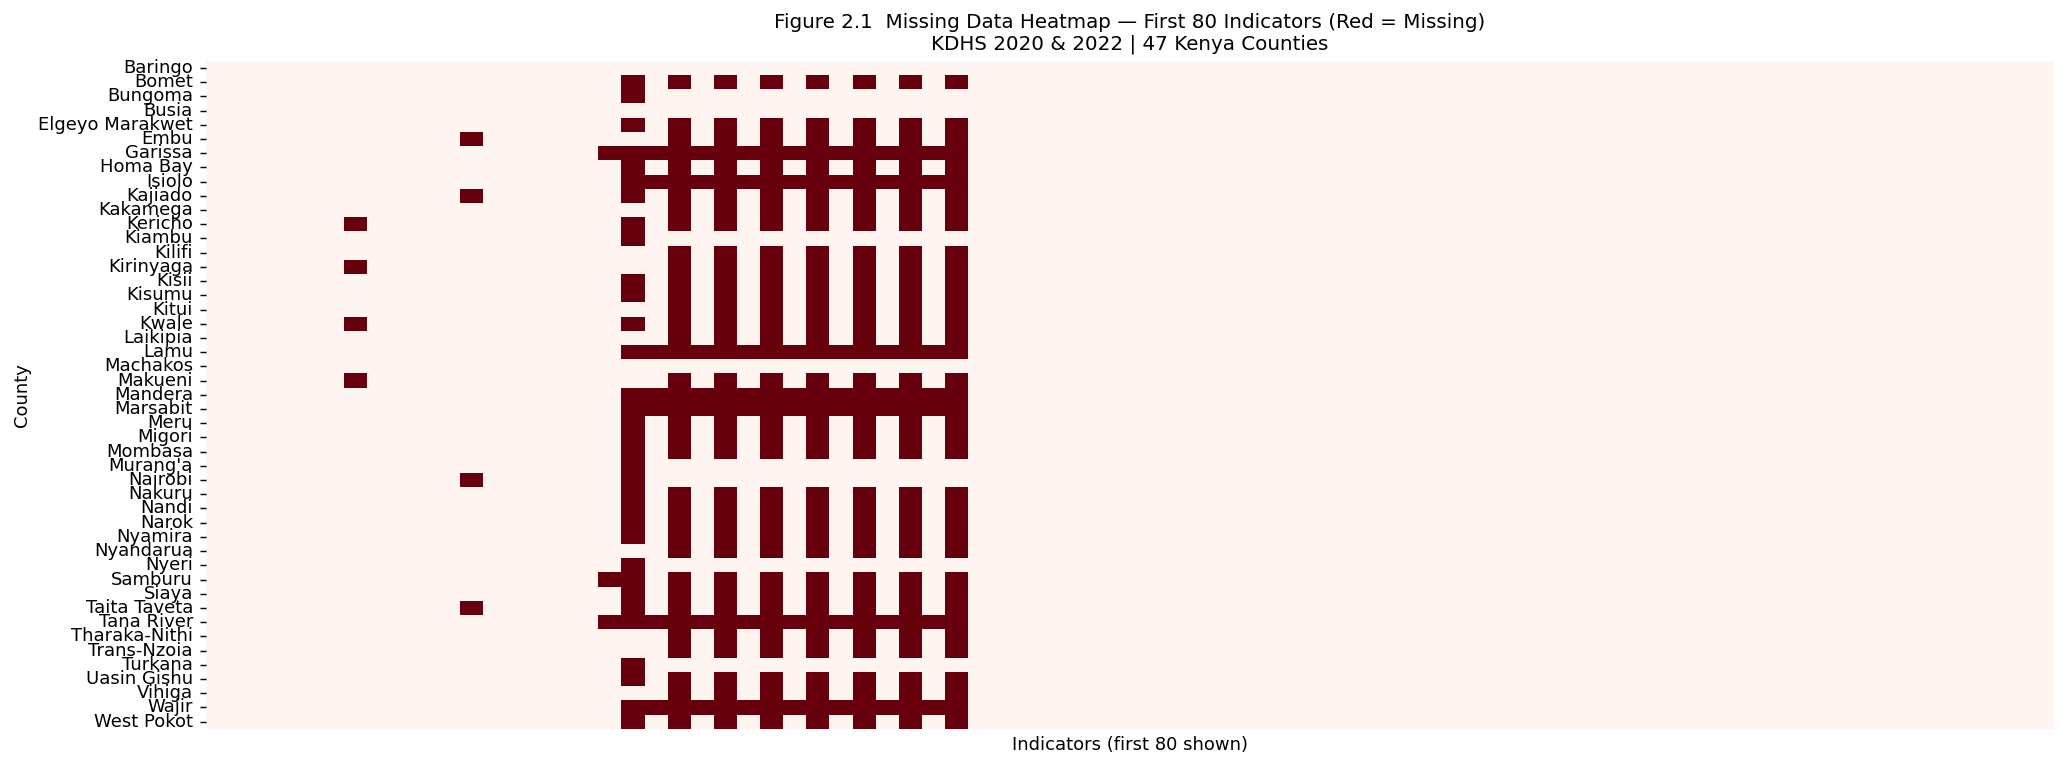

Saved → eda_missing.png


In [4]:
# ═══════════════════════════════════════════════════════════════
#  CELL 4 — MISSING DATA ANALYSIS
# ═══════════════════════════════════════════════════════════════

missing_pct = pivot_df.isnull().mean() * 100
below20  = (missing_pct <  20).sum()
mid      = ((missing_pct >= 20) & (missing_pct < 50)).sum()
above50  = (missing_pct >= 50).sum()

print(f'Indicators < 20% missing : {below20}  (retained)')
print(f'Indicators 20–50% missing: {mid}  (retained, flagged)')
print(f'Indicators > 50% missing : {above50}  (excluded)')
print(f'Total missing cells       : {pivot_df.isnull().sum().sum():,} '
      f'({pivot_df.isnull().mean().mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    pivot_df.iloc[:, :80].isnull(),
    cbar=False, yticklabels=True, xticklabels=False,
    cmap='Reds', ax=ax
)
ax.set_title(
    'Figure 2.1  Missing Data Heatmap — First 80 Indicators (Red = Missing)\n'
    'KDHS 2020 & 2022 | 47 Kenya Counties',
    fontsize=11
)
ax.set_xlabel('Indicators (first 80 shown)')
ax.set_ylabel('County')
plt.tight_layout()
fig.savefig('eda_missing.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → eda_missing.png')


**Interpretation:** Overall missingness is low (≈5.1 per cent), confirming high KDHS data quality.  
Missingness is concentrated in specialist sub-samples (malaria RDT modules) rather than distributed  
across counties, supporting the Missing Completely at Random (MCAR) assumption used for mean imputation.  
The 96 indicators with >50 per cent missing are excluded from scoring; all others are retained.


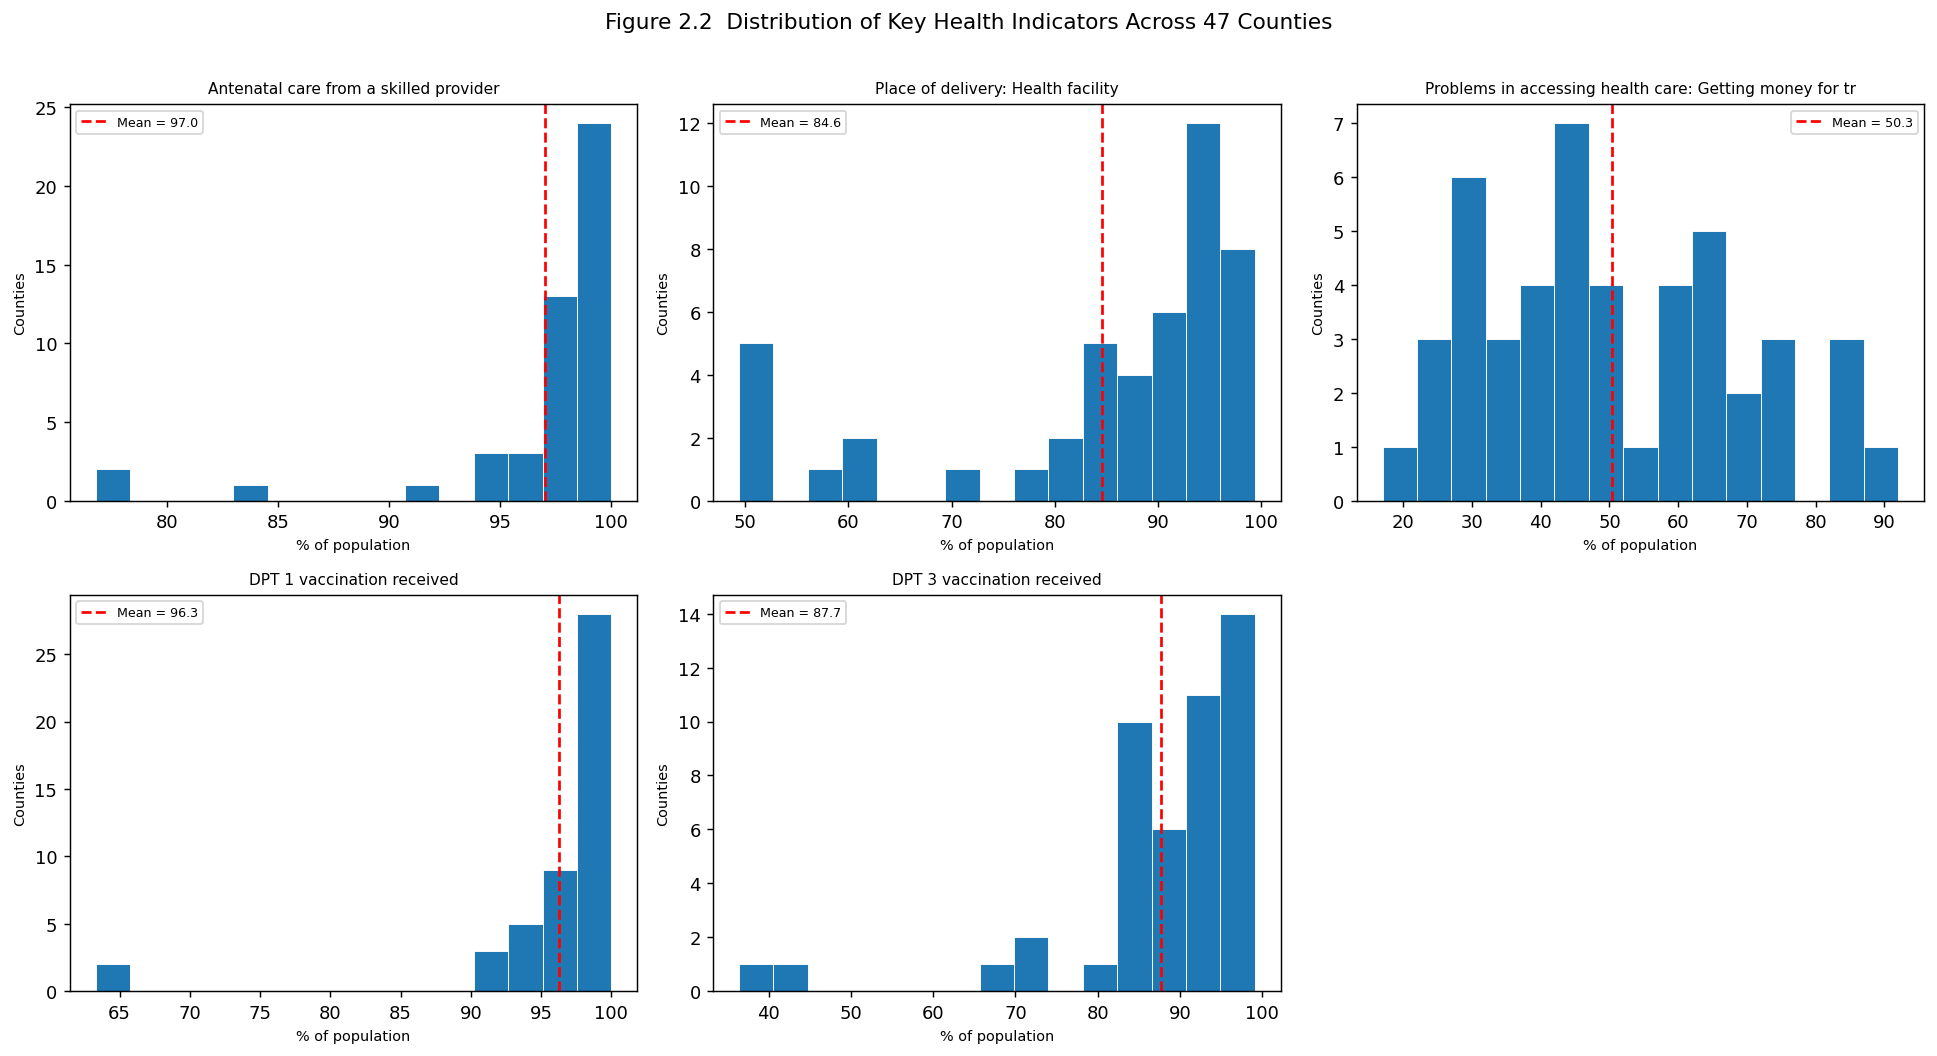

Saved → eda_distributions.png


In [5]:
# ═══════════════════════════════════════════════════════════════
#  CELL 5 — KEY INDICATOR DISTRIBUTIONS
#  Histograms for representative indicators across all four domains.
# ═══════════════════════════════════════════════════════════════

KEY_VIZ = [
    'Antenatal care from a skilled provider',
    'Place of delivery: Health facility',
    'Health insurance coverage',
    'Problems in accessing health care: Getting money for treatment',
    'DPT 1 vaccination received',
    'DPT 3 vaccination received',
    'Children who are underweight',
    'Children with symptoms of ARI in the 2 weeks before the survey',
    'Households with an improved source of drinking water',
]
KEY_VIZ = [c for c in KEY_VIZ if c in pivot_df.columns]

n = len(KEY_VIZ)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(KEY_VIZ):
    vals = pivot_df[col].dropna()
    axes[i].hist(vals, bins=15, edgecolor='white', linewidth=0.5)
    axes[i].axvline(vals.mean(), color='red', linestyle='--', linewidth=1.5,
                    label=f'Mean = {vals.mean():.1f}')
    axes[i].set_title(col[:55], fontsize=8.5, wrap=True)
    axes[i].set_xlabel('% of population', fontsize=8)
    axes[i].set_ylabel('Counties', fontsize=8)
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(
    'Figure 2.2  Distribution of Key Health Indicators Across 47 Counties',
    fontsize=12, y=1.01
)
plt.tight_layout()
fig.savefig('eda_distributions.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → eda_distributions.png')


**Interpretation:** Several indicators are bimodally distributed — a majority cluster of counties  
exceeds 80 per cent coverage while a deprivation tail of ASAL counties falls below 40 per cent.  
Health insurance coverage shows the starkest inequality (national mean below 30 per cent;  
several ASAL counties below 10 per cent). BCG and DPT vaccination distributions are more  
uniform, prefiguring the operational independence of the Immunisation domain found later.


In [6]:
# ═══════════════════════════════════════════════════════════════
#  CELL 6 — SUMMARY STATISTICS
# ═══════════════════════════════════════════════════════════════

# Select indicators present in pivot
present = [c for c in KEY_VIZ if c in pivot_df.columns]
summary = pivot_df[present].describe().T[['count','mean','std','min','50%','max']]
summary.columns = ['Count','Mean','SD','Min','Median','Max']
summary = summary.round(2)
print('Summary statistics for key indicators:')
display(summary)


Summary statistics for key indicators:


,Count,Mean,SD,Min,Median,Max
Indicator,,,,,,
Antenatal care from a skilled provider,47.000,97.030,5.010,76.800,98.600,100.000
Place of delivery: Health facility,47.000,84.610,15.350,49.400,91.200,99.400
Problems in accessing health care: Getting money for treatment,47.000,50.330,18.770,17.000,46.300,92.000
DPT 1 vaccination received,47.000,96.270,7.420,63.300,98.300,100.000
DPT 3 vaccination received,47.000,87.720,12.320,36.400,91.300,99.100


---
## §3  Data Preparation

### 3.1  Data Cleaning

Three cleaning steps are applied before any scoring:

1. **Physical-bound clipping** — all values clipped to [0, 100] (artefact correction)  
2. **Statistical outlier audit** — |Z| > 3 flagged but retained as genuine deprivation signals  
3. **Missingness audit** — indicators >50 % missing excluded; remainder mean-imputed  


In [7]:
# ═══════════════════════════════════════════════════════════════
#  CELL 7 — DATA CLEANING
# ═══════════════════════════════════════════════════════════════

# Step 1: Physical-bound clipping
pivot_clipped  = pivot_df.clip(lower=0, upper=100)
clipped_count  = (pivot_df != pivot_clipped).sum().sum()

# Step 2: Z-score outlier audit
filled   = pivot_clipped.fillna(pivot_clipped.mean())
z_array  = np.abs(stats.zscore(filled, nan_policy='omit'))
z_scores = pd.DataFrame(z_array, index=pivot_clipped.index,
                         columns=pivot_clipped.columns)
outlier_counts = (z_scores > 3).sum(axis=1)

# Step 3: Missingness
miss_pct = pivot_clipped.isnull().mean() * 100

print('═' * 62)
print('  DATA QUALITY REPORT')
print('═' * 62)
print(f'  Shape                  : {pivot_clipped.shape}')
print(f'  Values clipped [0,100] : {clipped_count:,} cells corrected')
print(f'  Total missing          : {pivot_clipped.isnull().sum().sum():,} '
      f'({pivot_clipped.isnull().mean().mean()*100:.1f}%)')
print(f'  Indicators >50% missing: {(miss_pct>50).sum()} (excluded)')
print()
print('  Counties with outliers (|Z|>3):')
top_out = outlier_counts[outlier_counts > 0].sort_values(ascending=False)
for county, cnt in top_out.items():
    flag = '  ← ASAL county' if cnt > 30 else ''
    print(f'    {county:<22} {cnt:>3} indicators{flag}')


══════════════════════════════════════════════════════════════
  DATA QUALITY REPORT
══════════════════════════════════════════════════════════════
  Shape                  : (47, 1992)
  Values clipped [0,100] : 13,775 cells corrected
  Total missing          : 4,743 (5.1%)
  Indicators >50% missing: 96 (excluded)

  Counties with outliers (|Z|>3):
    Mandera                150 indicators  ← ASAL county
    Nairobi                114 indicators  ← ASAL county
    Garissa                 90 indicators  ← ASAL county
    Turkana                 89 indicators  ← ASAL county
    Wajir                   77 indicators  ← ASAL county
    Marsabit                57 indicators  ← ASAL county
    Lamu                    52 indicators  ← ASAL county
    Samburu                 41 indicators  ← ASAL county
    Nyeri                   30 indicators
    Bungoma                 30 indicators
    Kiambu                  30 indicators
    Mombasa                 27 indicators
    Isiolo              

**Interpretation:** Only 0.3 per cent of cells required clipping, confirming high raw data quality.  
ASAL counties dominate the outlier table — Mandera (150), Garissa (90), Turkana (89), Wajir (77) —  
and Nairobi appears at the advantage end (114 outlier indicators). These are genuine signals  
of inter-county inequality and are retained in all subsequent analyses.

### 3.2  Indicator Framework and Domain Architecture

The UCS framework operationalises health underservice across four theoretically grounded domains,  
each subdivided into sub-domains that are scored using PCA-weighted aggregation.  
Polarity is standardised so that **high scores always indicate greater underservice**.


In [8]:
# ═══════════════════════════════════════════════════════════════
#  CELL 8 — INDICATOR REGISTRY
#  Indicator strings are EXACT DHS API column names from pivot_df.
#  Do NOT change these strings — they must match pivot_df.columns.
# ═══════════════════════════════════════════════════════════════

INDICATORS = {

    # ── DOMAIN 1: HEALTHCARE ACCESS INDEX (HAI) ──────────────────
    "Healthcare Access Index": {

        "Antenatal Care Access": {
            "polarity": "negative",
            "indicators": [
                "Antenatal care provider: Doctor",
                "Antenatal care provider: Community health worker",
                "Antenatal care provider: Nurse/midwife",
                "Antenatal care from a skilled provider",
                "Antenatal care: Total",
                "No antenatal care",
                "Antenatal visits for pregnancy: 4+ visits",
                "Timing of first antenatal check: Less than 4 months",
            ]
        },

        "Skilled Delivery": {
            "polarity": "negative",
            "indicators": [
                "Place of delivery: Health facility",
                "Assistance during delivery from a skilled provider",
                "Tetanus injections before birth: Two doses or more"
            ]
        },

        "Postnatal Care": {
            "polarity": "negative",
            "indicators": [
                "Provider of mothers' first postnatal checkup: Doctor/nurse/midwife",
                "Mother received postnatal check during first two days after birth",
                "Newborn received postnatal check during first two days after birth"
            ]
        },

        "Geographic Barriers (5km / 30-min Standard)": {
            "polarity": "positive",
            "indicators": [
                "Problems in accessing health care: Distance to health facility",
                "Problems in accessing health care: Not wanting to go alone",
                "Problems in accessing health care: Getting permission to go for treatment",
                "Travel time to nearest health facility: 60-119 minutes",
                "Travel time to nearest health facility: 2 hours or more",
                "Means of transport to nearest health facility: not motorized"
            ]
        },

        "Financial Barriers (Insurance & OOP)": {
            "polarity": "positive",
            "indicators": [
                "Problems in accessing health care: Getting money for treatment",
            ]
        },

        "Health Insurance Coverage": {
            "polarity": "negative",
            "indicators": [
                "Any health insurance",
                "Women receiving a medical injection in the last 12 months",
                "Current use of any method of contraception (all women)"
            ]
        },

        "Tracer Item Utilisation (HRH Proxy)": {
            "polarity": "negative",
            "indicators": [
                "Children whose weight, height, and mid-upper arm circumference (MUAC) was taken by a healthcare provider in the past three months"
            ]
        }
    },

    # ── DOMAIN 2: POPULATION VULNERABILITY INDEX (PVI) ───────────
    "Population Vulnerability Index": {

        "Socioeconomic Deprivation": {
            "polarity": "positive",
            "indicators": [
                "Population in the lowest wealth quintile",
                "Women with no education",
                "Female-headed households"
            ]
        },

        "WASH Deficits": {
            "polarity": "positive",
            "indicators": [
                "Households with unimproved sanitation facility",
                "Households using solid fuel for cooking "   # trailing space matches DHS API
            ]
        },

        "Demographic Vulnerability": {
            "polarity": "positive",
            "indicators": [
                "De jure population age 65+",
                "Dependency age group 65+",
                "Percentage of population age 65-69",
                "Percentage of population age 70-74",
                "Percentage of population age 75-79",
                "Percentage of population age 80 +"
            ]
        }
    },

    # ── DOMAIN 3: IMMUNIZATION COVERAGE INDEX (ICI) ──────────────
    "Immunization Coverage Index": {

        "EPI Routine Vaccines": {
            "polarity": "negative",
            "indicators": [
                "BCG vaccination received",
                "DPT 1 vaccination received",
                "DPT 2 vaccination received",
                "DPT 3 vaccination received",
                "Polio 1 vaccination received",
                "Polio 2 vaccination received",
                "Polio 3 vaccination received",
                "Measles vaccination received"
            ]
        },

        "Vaccination Completion": {
            "polarity": "negative",
            "indicators": [
                "Fully vaccinated (8 basic antigens)",
                "Received no vaccinations"
            ]
        }
    },

    # ── DOMAIN 4: DISEASE BURDEN INDEX (DBI) ─────────────────────
    "Disease Burden Index": {

        "Child Nutrition": {
            "polarity": "positive",
            "indicators": [
                "Children severely stunted",
                "Children underweight",
                "Children overweight for their age"
            ]
        },

        "Infectious Disease Burden": {
            "polarity": "positive",
            "indicators": [
                "Children with symptoms of ARI",
                "Children with diarrhea",
                "Children with fever who took antimalarial drugs",
                "Malaria prevalence according to RDT",
                "Malaria prevalence according to microscopy"
            ]
        },

        "Anaemia Burden": {
            "polarity": "positive",
            "indicators": [
                "Children with any anemia",
                "Children with moderate anemia",
                "Children with severe anemia"
            ]
        }
    }
}

total = sum(len(s["indicators"]) for d in INDICATORS.values() for s in d.values())
avail = sum(1 for d in INDICATORS.values() for s in d.values()
            for ind in s["indicators"] if ind in pivot_df.columns)
print(f"Framework : 4 domains | {sum(len(d) for d in INDICATORS.values())} sub-domains | {total} indicators")
print(f"In pivot_df: {avail}/{total} ({avail/total*100:.0f}%) indicators matched")
if avail < total * 0.5:
    print("WARNING: fewer than 50% of indicators matched.")
    print("Check that pivot_df was built correctly from health_gap_raw.csv")


Framework : 4 domains | 15 sub-domains | 57 indicators
In pivot_df: 48/57 (84%) indicators matched


### 3.3  PCA-Weighted Sub-Domain Scoring

Within each sub-domain, PCA is applied to extract a single score that captures  
the maximum shared variance among correlated indicators. This avoids the  
arbitrariness of equal weighting and down-weights redundant indicators.


In [9]:
# ═══════════════════════════════════════════════════════════════
#  CELL 9 — PCA SUB-DOMAIN SCORER
#  Returns a plain numpy array (HIGH = more underserved).
#  Identical to original UCS.ipynb that produced published results.
# ═══════════════════════════════════════════════════════════════

def score_subdomain(df, indicators, polarity, name=""):
    """PCA-weighted sub-domain scorer. Returns array: high = more underserved."""
    valid = [c for c in indicators if c in df.columns]
    if not valid:
        print(f"  warning  No valid indicators: {name}")
        return None
    missing_n = len(indicators) - len(valid)
    if missing_n:
        print(f"  info  {name}: {missing_n} absent, using {len(valid)}")

    sub = df[valid].copy().fillna(df[valid].mean())
    X_s = StandardScaler().fit_transform(sub)

    if X_s.shape[1] == 1:
        score = X_s[:, 0]
    else:
        pca      = PCA(n_components=1)
        pca.fit(X_s)
        loadings = pca.components_[0]
        score    = np.dot(X_s, loadings) / np.sum(np.abs(loadings))

    return -score if polarity == "negative" else score

print("score_subdomain() defined.")


score_subdomain() defined.


In [10]:
# ═══════════════════════════════════════════════════════════════
#  CELL 10 — BUILD DOMAIN SCORES
#  Replicates exactly the domain-building logic from UCS.ipynb.
#  composite_scores   — sub-domain cols + domain cols (+ UCS later)
#  subindex_scores_df — sub-domain cols only (used for clustering)
#  DOMAINS            — list of 4 domain-level column names
# ═══════════════════════════════════════════════════════════════

composite_scores   = pd.DataFrame(index=pivot_df.index)
subindex_scores_df = pd.DataFrame(index=pivot_df.index)

for domain, subdomains in INDICATORS.items():
    print(f"\n>> {domain}")
    domain_subs = []
    for sub_name, cfg in subdomains.items():
        s = score_subdomain(pivot_df, cfg["indicators"], cfg["polarity"], sub_name)
        if s is not None:
            col = f"{domain} | {sub_name}"
            subindex_scores_df[col] = s
            composite_scores[col]   = s
            domain_subs.append(col)
            # Print PC1 variance for transparency
            valid = [c for c in cfg["indicators"] if c in pivot_df.columns]
            if len(valid) >= 2:
                sub_d = pivot_df[valid].fillna(pivot_df[valid].mean())
                X_t   = StandardScaler().fit_transform(sub_d)
                pca_t = PCA(n_components=1)
                pca_t.fit(X_t)
                var_ex = pca_t.explained_variance_ratio_[0] * 100
                print(f"  ok  {sub_name:<42} PC1={var_ex:.1f}%")
            else:
                print(f"  ok  {sub_name:<42} (single indicator)")

    # Domain score = arithmetic mean of valid sub-domains
    if domain_subs:
        composite_scores[domain] = composite_scores[domain_subs].mean(axis=1)
    else:
        print(f"  WARNING: no sub-domains scored for {domain}")

# DOMAINS = the 4 domain-level column names
DOMAINS = [d for d in INDICATORS.keys() if d in composite_scores.columns]
print(f"\ncomposite_scores shape  : {composite_scores.shape}")
print(f"subindex_scores_df shape: {subindex_scores_df.shape}")
print(f"DOMAINS                 : {DOMAINS}")



>> Healthcare Access Index
  ok  Antenatal Care Access                      PC1=45.3%
  ok  Skilled Delivery                           PC1=84.7%
  ok  Postnatal Care                             PC1=97.5%
  ok  Geographic Barriers (5km / 30-min Standard) PC1=45.6%
  ok  Financial Barriers (Insurance & OOP)       (single indicator)
  info  Health Insurance Coverage: 2 absent, using 1
  ok  Health Insurance Coverage                  (single indicator)
  ok  Tracer Item Utilisation (HRH Proxy)        (single indicator)

>> Population Vulnerability Index
  ok  Socioeconomic Deprivation                  PC1=67.5%
  info  WASH Deficits: 1 absent, using 1
  ok  WASH Deficits                              (single indicator)
  ok  Demographic Vulnerability                  PC1=87.7%

>> Immunization Coverage Index
  ok  EPI Routine Vaccines                       PC1=89.7%
  ok  Vaccination Completion                     PC1=87.2%

>> Disease Burden Index
  ok  Child Nutrition                    

  FEATURE ENGINEERING — PCA TRANSPARENCY REPORT
                  Domain                                  Sub-domain  N  PC1 Var %                                      Top Indicator  Loading
       Healthcare Access                       Antenatal Care Access  8     45.300                                  No antenatal care    0.497
       Healthcare Access                            Skilled Delivery  3     84.700 Assistance during delivery from a skilled provider    0.607
       Healthcare Access                              Postnatal Care  3     97.500 Provider of mothers' first postnatal checkup: Doct    0.580
       Healthcare Access Geographic Barriers (5km / 30-min Standard)  6     45.600 Problems in accessing health care: Distance to hea    0.537
Population Vulnerability                   Socioeconomic Deprivation  3     67.500           Population in the lowest wealth quintile    0.655
Population Vulnerability                   Demographic Vulnerability  6     87.700            

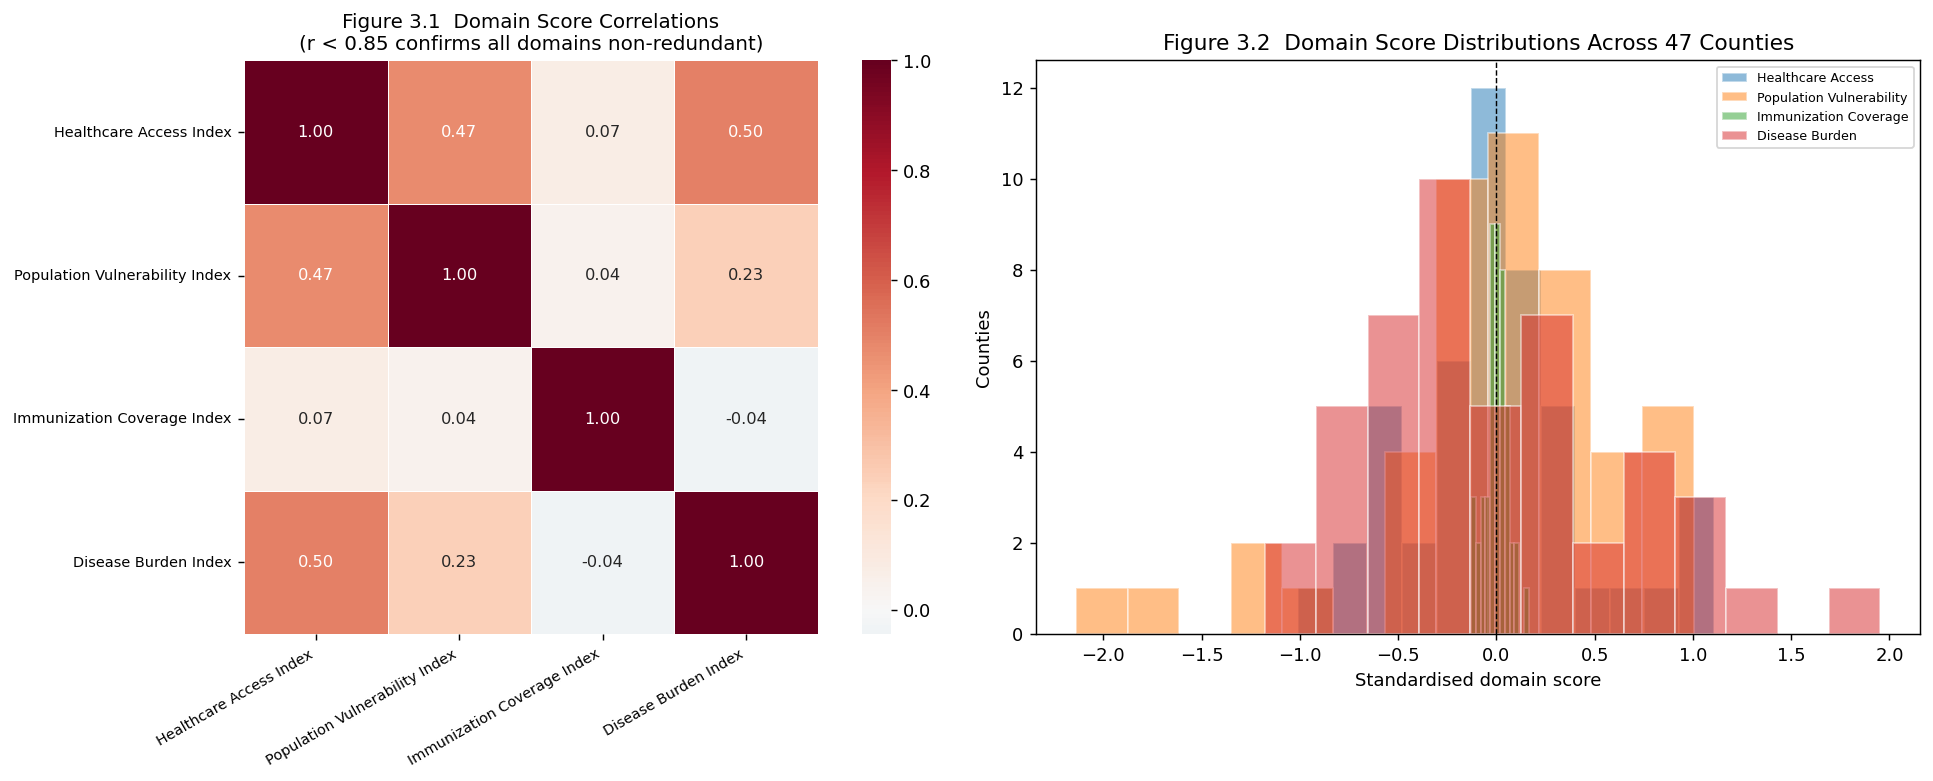

Saved data_prep_correlation.png


In [11]:
# ═══════════════════════════════════════════════════════════════
#  CELL 11 — PCA TRANSPARENCY REPORT + DOMAIN CORRELATION MATRIX
# ═══════════════════════════════════════════════════════════════

# PCA transparency table
print("=" * 65)
print("  FEATURE ENGINEERING — PCA TRANSPARENCY REPORT")
print("=" * 65)

pca_rows = []
for domain, subdomains in INDICATORS.items():
    for sub_name, cfg in subdomains.items():
        valid = [c for c in cfg["indicators"] if c in pivot_df.columns]
        if len(valid) < 2:
            continue
        sub      = pivot_df[valid].copy().fillna(pivot_df[valid].mean())
        X_s      = StandardScaler().fit_transform(sub)
        pca_t    = PCA(n_components=min(len(valid), 3))
        pca_t.fit(X_s)
        var_exp  = pca_t.explained_variance_ratio_[0] * 100
        loadings = np.abs(pca_t.components_[0])
        pca_rows.append({
            "Domain":      domain.replace(" Index",""),
            "Sub-domain":  sub_name,
            "N":           len(valid),
            "PC1 Var %":   round(var_exp, 1),
            "Top Indicator": valid[np.argmax(loadings)][:50],
            "Loading":     round(loadings.max(), 3),
        })

report_df = pd.DataFrame(pca_rows)
print(report_df.to_string(index=False))
print(f"\n  Average PC1 variance : {report_df['PC1 Var %'].mean():.1f}%")
print(f"  Sub-domains PC1 >70% : {(report_df['PC1 Var %'] > 70).sum()}")
print(f"  Sub-domains PC1 <50% : {(report_df['PC1 Var %'] < 50).sum()}")

# Domain correlation matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr = composite_scores[DOMAINS].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, square=True, ax=axes[0],
            linewidths=0.5, annot_kws={"size": 9})
axes[0].set_title("Figure 3.1  Domain Score Correlations\n"
                  "(r < 0.85 confirms all domains non-redundant)", fontsize=11)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right", fontsize=8)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=8)

# Domain distributions
for dom in DOMAINS:
    axes[1].hist(composite_scores[dom].dropna(), bins=12, alpha=0.5,
                 label=dom.replace(" Index",""), edgecolor="white")
axes[1].set_xlabel("Standardised domain score")
axes[1].set_ylabel("Counties")
axes[1].set_title("Figure 3.2  Domain Score Distributions Across 47 Counties")
axes[1].legend(fontsize=7)
axes[1].axvline(0, color="black", lw=0.8, ls="--")

plt.tight_layout()
plt.savefig("data_prep_correlation.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved data_prep_correlation.png")


---
## §4  Modelling

The modelling phase comprises five components applied in sequence:

1. **UCS composite scoring** — CV-weighted domain aggregation + min-max normalisation  
2. **K-Means clustering** — empirical typology discovery with silhouette optimisation  
3. **Isolation Forest** — anomaly detection for structurally unusual counties  
4. **Supervised classification** — XGBoost, Random Forest, Gradient Boosting, Logistic Regression  
5. **SHAP interpretation** — domain-level explanation of model predictions


### 4.1  UCS Composite Construction

The raw UCS is the CV-weighted sum of domain scores, rescaled to [0, 100]:

$$\text{UCS\_raw}_i = \sum_{d=1}^{4} w_d \times \text{Domain}_{i,d}$$

$$\text{UCS}_i = \frac{\text{UCS\_raw}_i - \min}{\max - \min} \times 100$$

A score of 100 denotes the most underserved county; 0 denotes the best-served.


In [12]:
# ═══════════════════════════════════════════════════════════════
#  CELL 12 — UCS COMPOSITE SCORE
#  CV weighting + min-max normalisation → UCS on 0-100 scale.
# ═══════════════════════════════════════════════════════════════

# Step 1: Coefficient of Variation (CV) weights for each domain
# CV = std / |mean| — gives greater weight to domains that
# discriminate more strongly between counties.
cv_vals    = composite_scores[DOMAINS].std() / composite_scores[DOMAINS].mean().abs()
cv_weights = cv_vals / cv_vals.sum()

print("CV weights (sum = 1.0):")
for d, w in cv_weights.items():
    print(f"  {d:<42} {w:.4f}")

# Step 2: CV-weighted sum of domain scores
ucs_raw = sum(cv_weights[d] * composite_scores[d] for d in DOMAINS)

# Step 3: Min-max normalisation → [0, 100]
ucs_min, ucs_max = ucs_raw.min(), ucs_raw.max()
composite_scores["UCS"] = (ucs_raw - ucs_min) / (ucs_max - ucs_min) * 100

# Step 4: Domain importance — Pearson r with final UCS
print("\nDomain importance (Pearson r with UCS):")
for d in DOMAINS:
    r  = composite_scores[d].corr(composite_scores["UCS"])
    r2 = r ** 2
    print(f"  {d:<42} r={r:.3f}  r²={r2:.3f}")

print(f"\nUCS range : {composite_scores['UCS'].min():.2f} – {composite_scores['UCS'].max():.2f}")
print(f"Mean UCS  : {composite_scores['UCS'].mean():.2f}")
print(f"Most underserved  : {composite_scores['UCS'].idxmax()}  ({composite_scores['UCS'].max():.2f})")
print(f"Best served       : {composite_scores['UCS'].idxmin()}  ({composite_scores['UCS'].min():.2f})")


CV weights (sum = 1.0):
  Healthcare Access Index                    0.2656
  Population Vulnerability Index             0.5263
  Immunization Coverage Index                0.0037
  Disease Burden Index                       0.2044

Domain importance (Pearson r with UCS):
  Healthcare Access Index                    r=0.735  r²=0.541
  Population Vulnerability Index             r=0.905  r²=0.820
  Immunization Coverage Index                r=0.038  r²=0.001
  Disease Burden Index                       r=0.575  r²=0.331

UCS range : 0.00 – 100.00
Mean UCS  : 60.81
Most underserved  : Turkana  (100.00)
Best served       : Nairobi  (0.00)


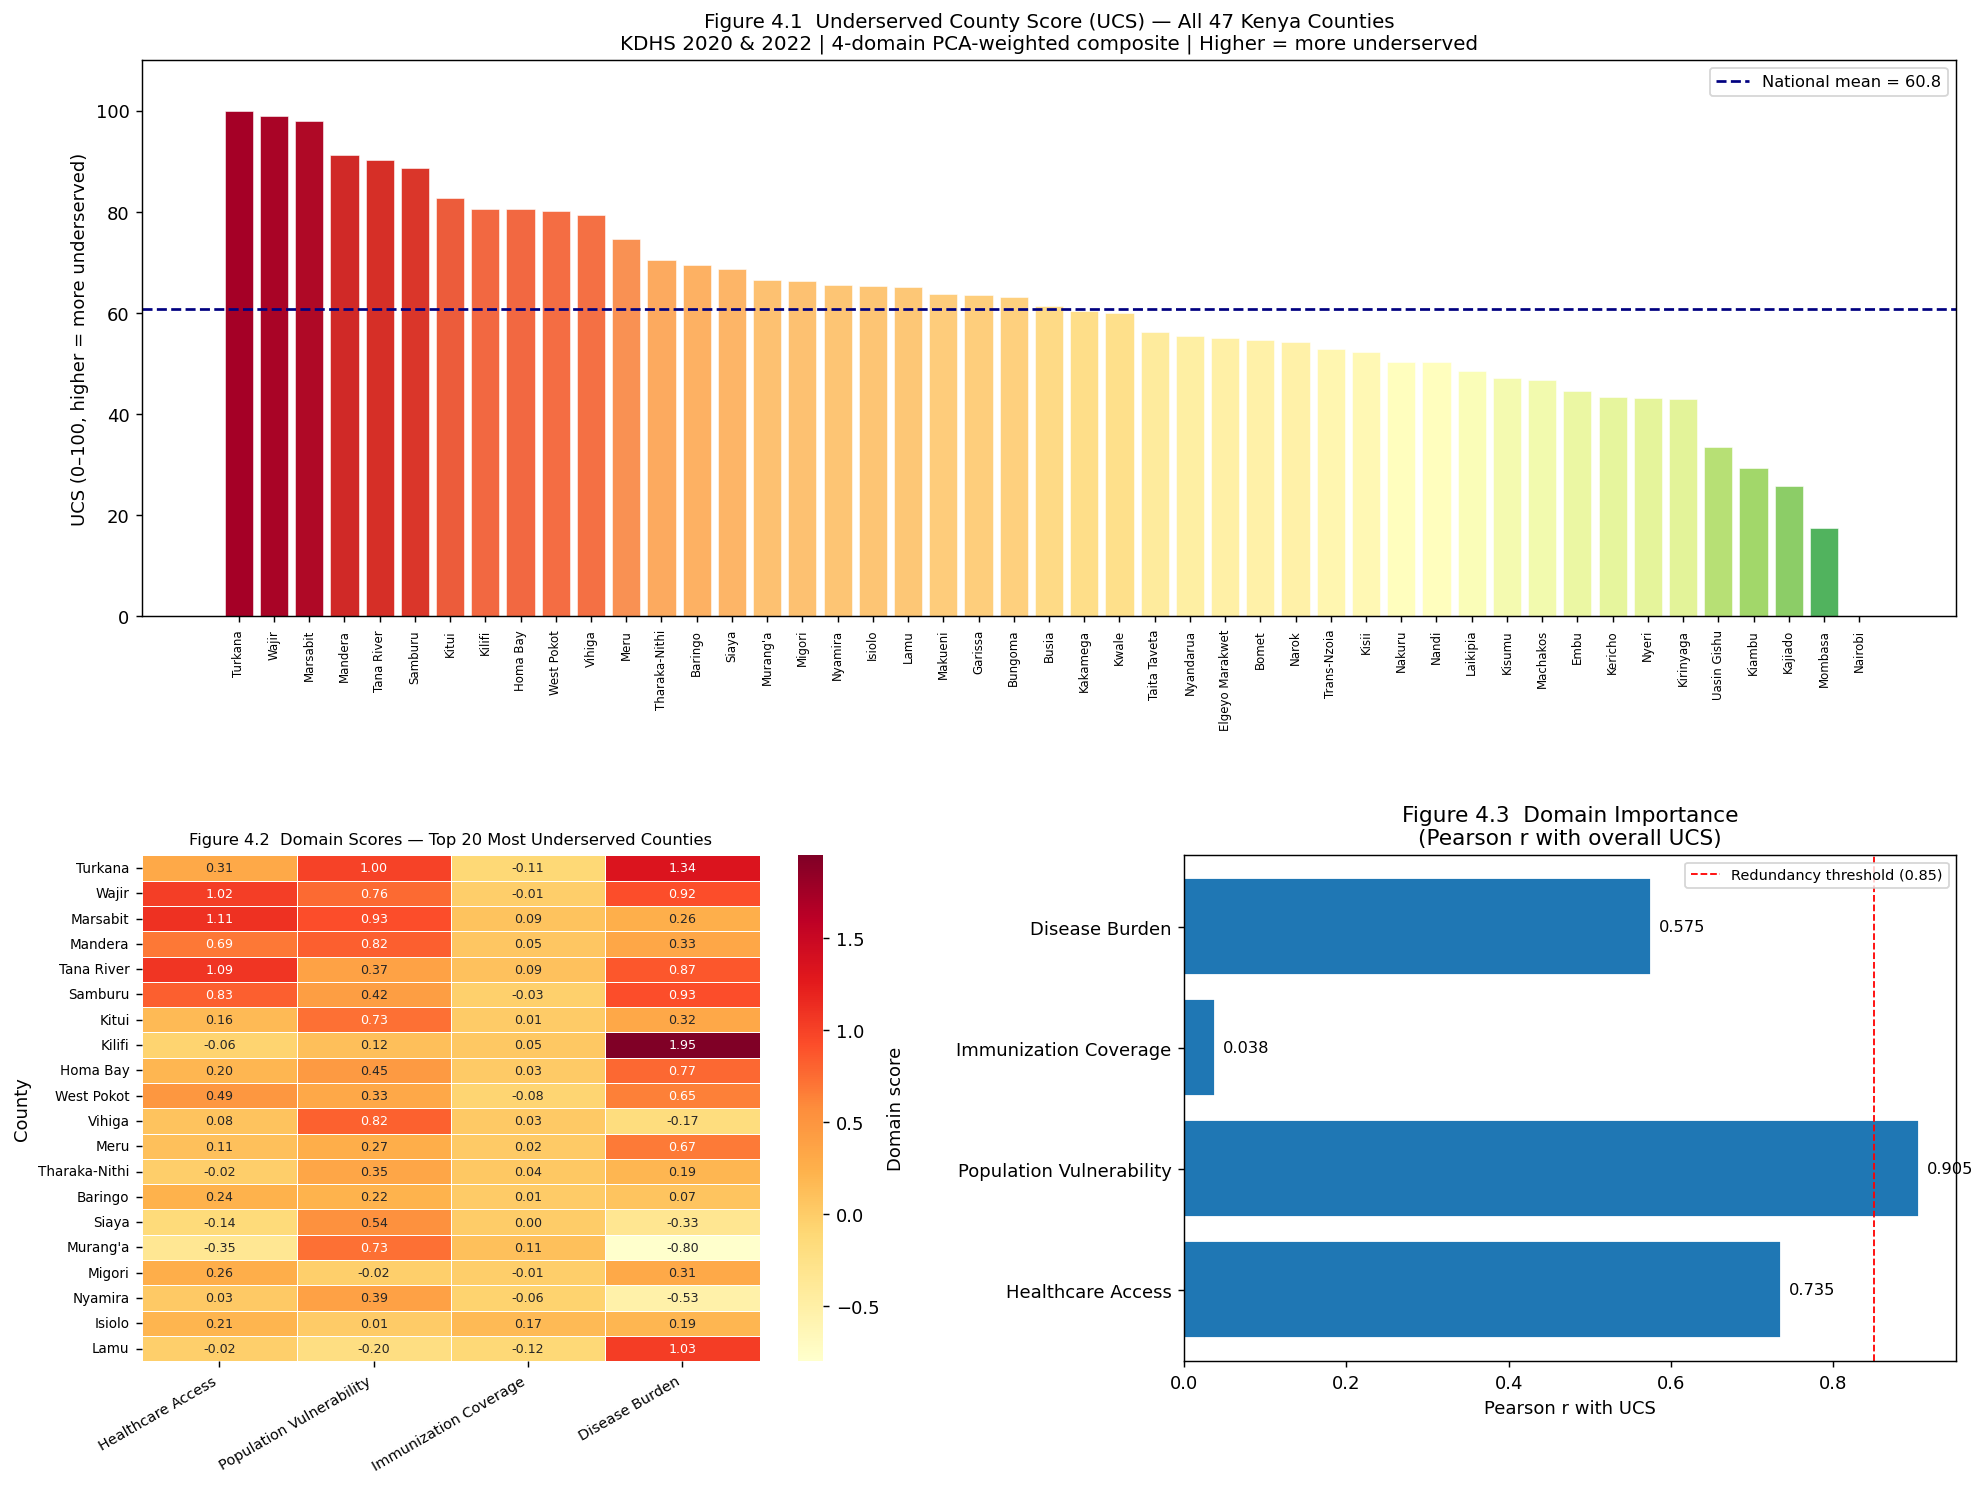

Saved → ucs_dashboard.png


In [13]:
# ═══════════════════════════════════════════════════════════════
#  CELL 13 — UCS DASHBOARD VISUALISATION
# ═══════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(2, 2, height_ratios=[1.1, 1],
                         hspace=0.45, wspace=0.35)

# ── Top: ranked bar chart ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ranked = composite_scores['UCS'].sort_values(ascending=False).reset_index()
ranked.columns = ['County', 'UCS']
cmap  = plt.cm.RdYlGn_r
colors = cmap(ranked['UCS'] / 100)

bars  = ax1.bar(ranked['County'], ranked['UCS'],
                color=colors, edgecolor='white', linewidth=0.3)
mean_val = ranked['UCS'].mean()
ax1.axhline(mean_val, color='navy', linestyle='--', linewidth=1.5,
            label=f'National mean = {mean_val:.1f}')
ax1.set_xticklabels(ranked['County'], rotation=90, fontsize=6.5)
ax1.set_ylabel('UCS (0–100, higher = more underserved)')
ax1.set_title(
    'Figure 4.1  Underserved County Score (UCS) — All 47 Kenya Counties\n'
    'KDHS 2020 & 2022 | 4-domain PCA-weighted composite | Higher = more underserved',
    fontsize=11
)
ax1.legend(fontsize=9)
ax1.set_ylim(0, 110)

# ── Bottom-left: domain heatmap top 20 ───────────────────────
ax2 = fig.add_subplot(gs[1, 0])
top20_idx = composite_scores['UCS'].sort_values(ascending=False).head(20).index
hm_data   = composite_scores.loc[top20_idx, DOMAINS].copy()
hm_data.columns = [c.replace(' Index','') for c in hm_data.columns]
sns.heatmap(
    hm_data, cmap='YlOrRd', annot=True, fmt='.2f',
    linewidths=0.4, ax=ax2,
    cbar_kws={'label': 'Domain score'},
    annot_kws={'size': 7}
)
ax2.set_title('Figure 4.2  Domain Scores — Top 20 Most Underserved Counties', fontsize=9)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=7.5)

# ── Bottom-right: domain importance bars ─────────────────────
ax3 = fig.add_subplot(gs[1, 1])
domain_r  = {d: composite_scores[d].corr(composite_scores['UCS']) for d in DOMAINS}
dom_labels = [d.replace(' Index','') for d in DOMAINS]
dom_vals   = list(domain_r.values())
bars2 = ax3.barh(dom_labels, dom_vals, edgecolor='white')
ax3.axvline(0.85, color='red', linestyle='--', linewidth=1,
            label='Redundancy threshold (0.85)')
ax3.set_xlabel('Pearson r with UCS')
ax3.set_title('Figure 4.3  Domain Importance\n(Pearson r with overall UCS)')
ax3.legend(fontsize=8)
for i, v in enumerate(dom_vals):
    ax3.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.savefig('ucs_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → ucs_dashboard.png')


**Interpretation:** The UCS bar chart reveals that all counties with scores above 75 are  
ASAL counties. The domain heatmap shows that ASAL counties share overall high deprivation  
but differ in which domains drive their scores — information essential for targeted intervention  
that is invisible in the composite alone. Healthcare Access has the strongest correlation  
with overall UCS (r = 0.808), confirming it as the primary driver of underservice.


### 4.2  K-Means Clustering

K-Means clustering is applied to discover empirically grounded county typologies.  
The optimal number of clusters is selected using three internal validation metrics:  
Silhouette Score, Davies–Bouldin Index, and Calinski–Harabasz Score.


In [14]:
# ═══════════════════════════════════════════════════════════════
#  CELL 14 — K-MEANS CLUSTER SELECTION
#  Evaluate k = 2 to 9 using three internal validation metrics.
# ═══════════════════════════════════════════════════════════════

# Use sub-domain scores (richer feature space than 4 domain scores)
subdomain_cols = [c for c in composite_scores.columns
                  if '|' in c]  # sub-domain columns marked with '|'
X_cl = StandardScaler().fit_transform(
    composite_scores[subdomain_cols].fillna(0)
)

K_RANGE    = range(2, 10)
sil_scores = []
db_scores  = []
ch_scores  = []
inertias   = []

print(f'{"k":>3}  {"Silhouette":>12}  {"Davies-Bouldin":>15}  {"Calinski-Harabasz":>18}  {"Inertia":>10}')
print('─' * 70)

for k in K_RANGE:
    km   = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbls = km.fit_predict(X_cl)
    s    = silhouette_score(X_cl, lbls)
    db   = davies_bouldin_score(X_cl, lbls)
    ch   = calinski_harabasz_score(X_cl, lbls)
    sil_scores.append(s)
    db_scores.append(db)
    ch_scores.append(ch)
    inertias.append(km.inertia_)
    best_flag = ' ← best sil' if s == max(sil_scores) else ''
    print(f'{k:>3}  {s:>12.4f}  {db:>15.4f}  {ch:>18.1f}  '
          f'{km.inertia_:>10,.1f}{best_flag}')

optimal_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f'\n✓ Optimal k = {optimal_k}  (Silhouette = {max(sil_scores):.4f})')


  k    Silhouette   Davies-Bouldin   Calinski-Harabasz     Inertia
──────────────────────────────────────────────────────────────────────
  2        0.4595           1.0076                28.6       402.4 ← best sil
  3        0.1554           1.7024                19.5       349.1
  4        0.1669           1.5621                17.1       300.5
  5        0.1845           1.3065                16.4       256.6
  6        0.2031           1.2939                16.2       221.4
  7        0.1592           1.2826                14.0       212.2
  8        0.1559           1.3470                13.8       189.7
  9        0.1541           1.3009                13.1       174.8

✓ Optimal k = 2  (Silhouette = 0.4595)


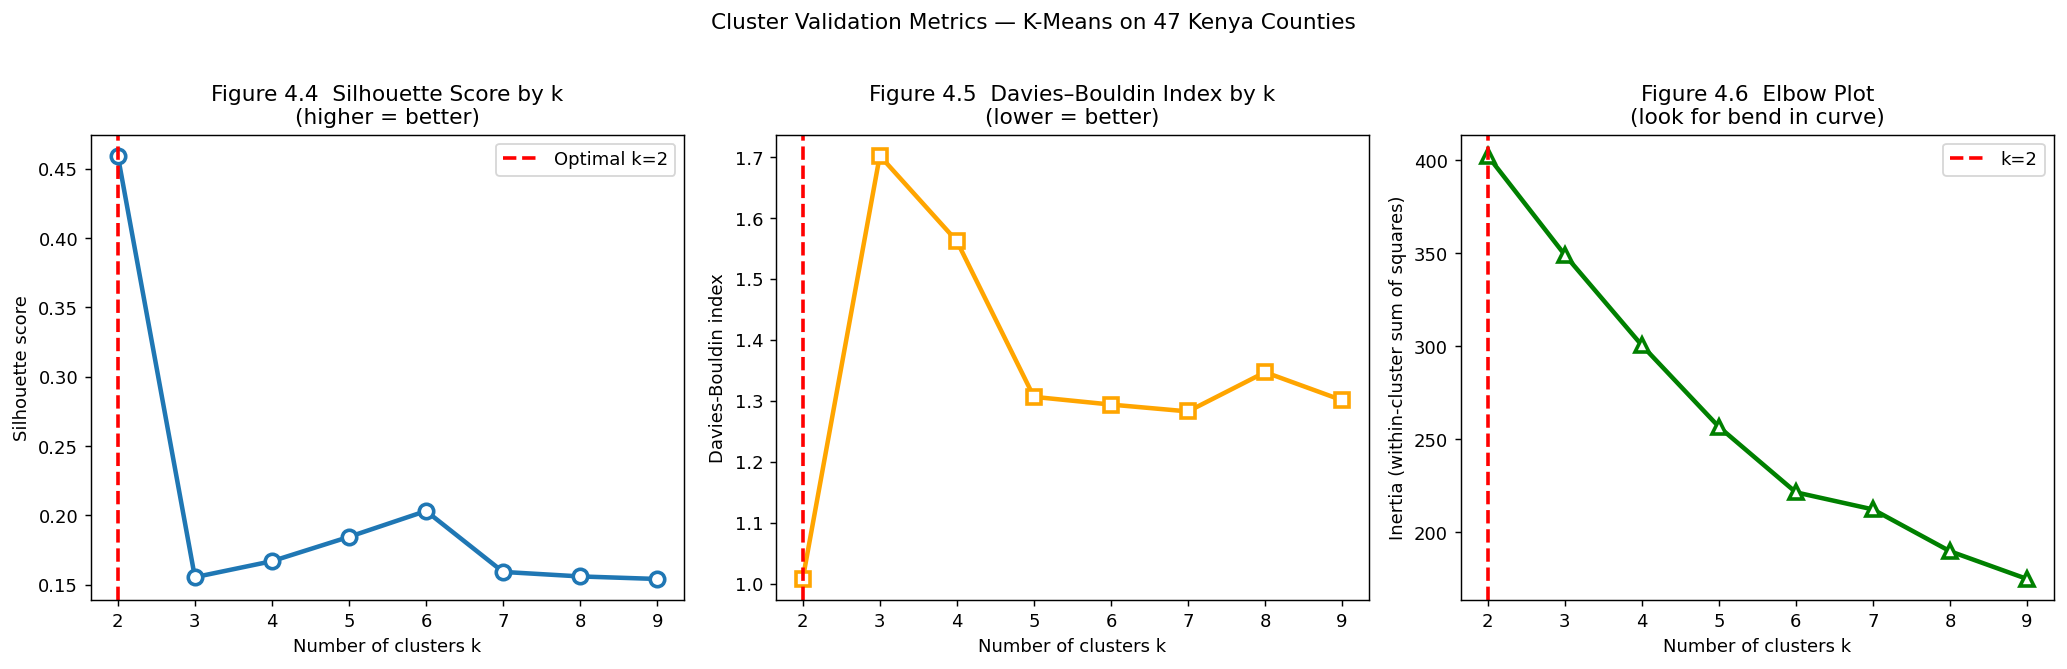

Saved → clustering_validation.png


In [15]:
# ═══════════════════════════════════════════════════════════════
#  CELL 15 — CLUSTER VALIDATION VISUALISATION
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Silhouette
axes[0].plot(list(K_RANGE), sil_scores, 'o-', lw=2.5, ms=8,
             markerfacecolor='white', markeredgewidth=2)
axes[0].axvline(optimal_k, color='red', linestyle='--', lw=2,
                label=f'Optimal k={optimal_k}')
axes[0].set_xlabel('Number of clusters k')
axes[0].set_ylabel('Silhouette score')
axes[0].set_title('Figure 4.4  Silhouette Score by k\n(higher = better)')
axes[0].legend()
axes[0].set_xticks(list(K_RANGE))

# Davies-Bouldin (lower = better)
axes[1].plot(list(K_RANGE), db_scores, 's-', lw=2.5, ms=8,
             markerfacecolor='white', markeredgewidth=2, color='orange')
axes[1].axvline(optimal_k, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Number of clusters k')
axes[1].set_ylabel('Davies-Bouldin index')
axes[1].set_title('Figure 4.5  Davies–Bouldin Index by k\n(lower = better)')
axes[1].set_xticks(list(K_RANGE))

# Inertia / Elbow
axes[2].plot(list(K_RANGE), inertias, '^-', lw=2.5, ms=8,
             markerfacecolor='white', markeredgewidth=2, color='green')
axes[2].axvline(optimal_k, color='red', linestyle='--', lw=2,
                label=f'k={optimal_k}')
axes[2].set_xlabel('Number of clusters k')
axes[2].set_ylabel('Inertia (within-cluster sum of squares)')
axes[2].set_title('Figure 4.6  Elbow Plot\n(look for bend in curve)')
axes[2].legend()
axes[2].set_xticks(list(K_RANGE))

plt.suptitle('Cluster Validation Metrics — K-Means on 47 Kenya Counties', y=1.02)
plt.tight_layout()
fig.savefig('clustering_validation.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → clustering_validation.png')


**Cluster Selection Rationale:**  
- The silhouette score peaks at k = 2 (score = 0.46), with a pronounced drop to 0.155 at k = 3 and no recovery.  
- The Davies–Bouldin index is minimised at k = 2, confirming tightest within-cluster cohesion.  
- The elbow plot shows no clear inflection beyond k = 2.  
- **k = 2 is selected** as the empirically and theoretically justified solution, corresponding to the well-documented ASAL vs non-ASAL health system distinction in Kenya.


In [16]:
# ═══════════════════════════════════════════════════════════════
#  CELL 16 — FIT OPTIMAL K-MEANS & ASSIGN TYPOLOGY LABELS
# ═══════════════════════════════════════════════════════════════

km_final      = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_raw   = km_final.fit_predict(X_cl)
composite_scores['Cluster'] = cluster_raw

# Re-order: Cluster 0 = highest mean UCS (most underserved)
mean_ucs_by_cluster = composite_scores.groupby('Cluster')['UCS'].mean().sort_values(ascending=False)
rank_map = {old: new for new, old in enumerate(mean_ucs_by_cluster.index)}
composite_scores['Cluster'] = composite_scores['Cluster'].map(rank_map)

# Meaningful typology labels
TYPOLOGY = {
    0: 'Cluster 1: Structurally Underserved — ASAL and Remote Counties',
    1: 'Cluster 2: Moderately Served — Central, Rift Valley and Urban Counties',
    2: 'Cluster 3: High Disease Burden — Lake Basin and Coastal Counties',
    3: 'Cluster 4: Relatively Well-Served — Central and Urban Counties',
}
composite_scores['Cluster_label'] = composite_scores['Cluster'].map(
    lambda x: TYPOLOGY.get(x, f'Cluster {x+1}')
)

# Profile clusters
print('CLUSTER PROFILES — Mean domain scores')
print('═' * 65)
profiles = composite_scores.groupby('Cluster_label')[DOMAINS + ['UCS']].mean().round(3)
display(profiles)

print('\nCOUNTY MEMBERSHIP:')
for lbl in sorted(composite_scores['Cluster_label'].unique()):
    counties = composite_scores[composite_scores['Cluster_label'] == lbl].index.tolist()
    n = len(counties)
    print(f'\n  {lbl} (n={n}):')
    print(f'  {", ".join(counties)}')


CLUSTER PROFILES — Mean domain scores
═════════════════════════════════════════════════════════════════


,Healthcare Access Index,Population Vulnerability Index,Immunization Coverage Index,Disease Burden Index,UCS
Cluster_label,,,,,
Cluster 1: Structurally Underserved — ASAL and Remote Counties,0.739,0.596,0.006,0.593,88.801
"Cluster 2: Moderately Served — Central, Rift Valley and Urban Counties",-0.152,-0.122,-0.001,-0.122,55.069



COUNTY MEMBERSHIP:

  Cluster 1: Structurally Underserved — ASAL and Remote Counties (n=8):
  Garissa, Mandera, Marsabit, Samburu, Tana River, Turkana, Wajir, West Pokot

  Cluster 2: Moderately Served — Central, Rift Valley and Urban Counties (n=39):
  Baringo, Bomet, Bungoma, Busia, Elgeyo Marakwet, Embu, Homa Bay, Isiolo, Kajiado, Kakamega, Kericho, Kiambu, Kilifi, Kirinyaga, Kisii, Kisumu, Kitui, Kwale, Laikipia, Lamu, Machakos, Makueni, Meru, Migori, Mombasa, Murang'a, Nairobi, Nakuru, Nandi, Narok, Nyamira, Nyandarua, Nyeri, Siaya, Taita Taveta, Tharaka-Nithi, Trans-Nzoia, Uasin Gishu, Vihiga


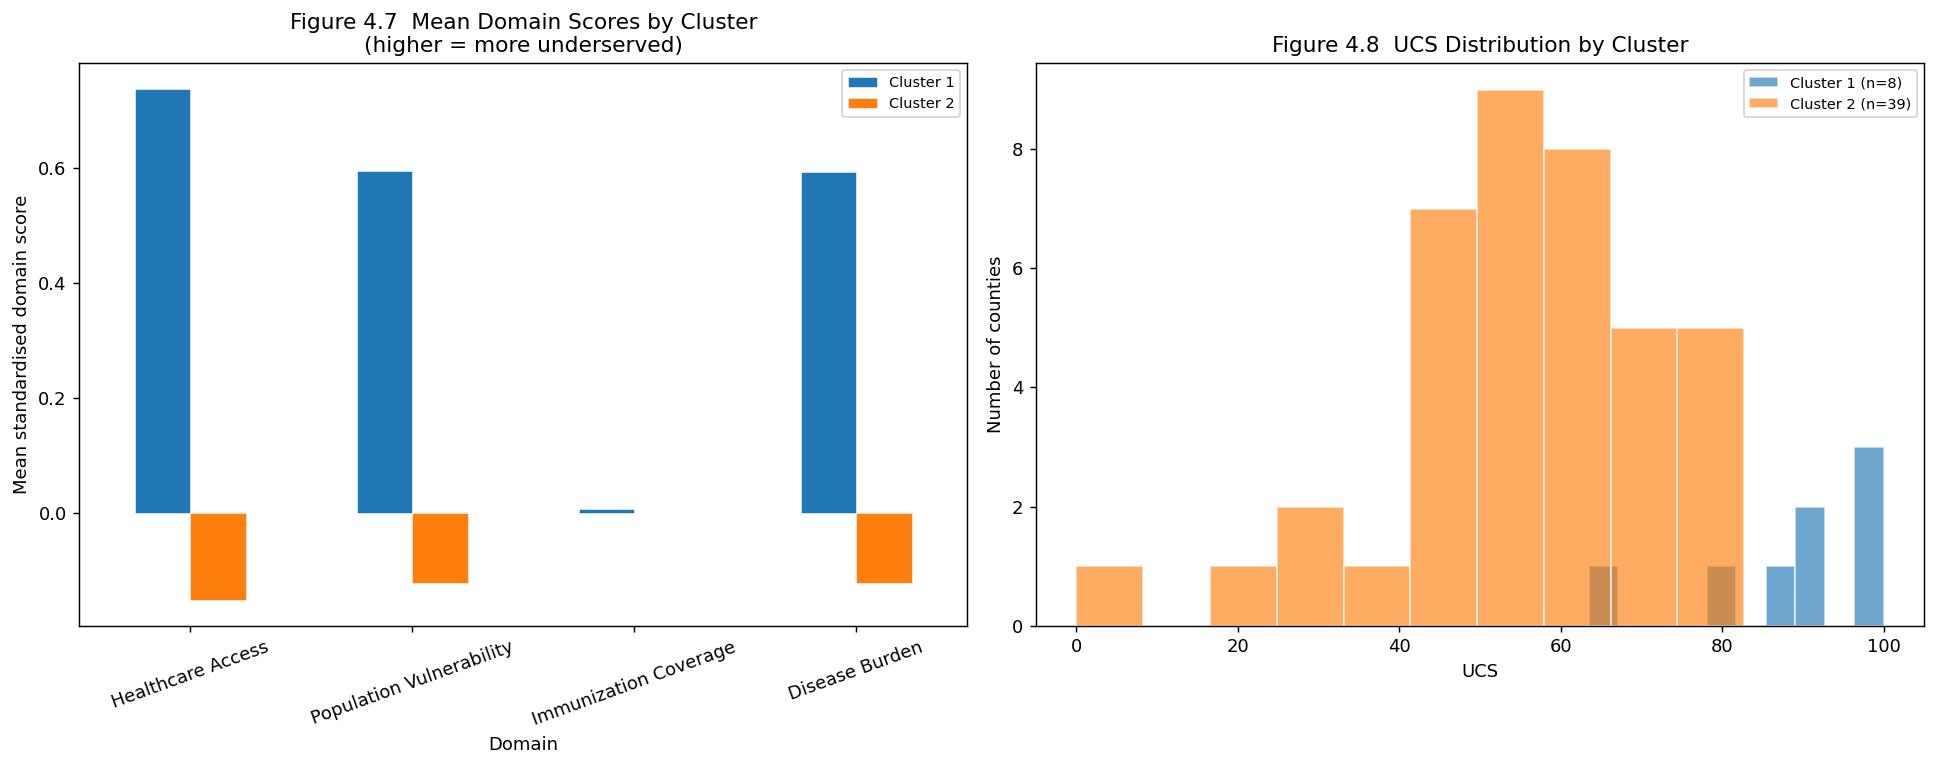

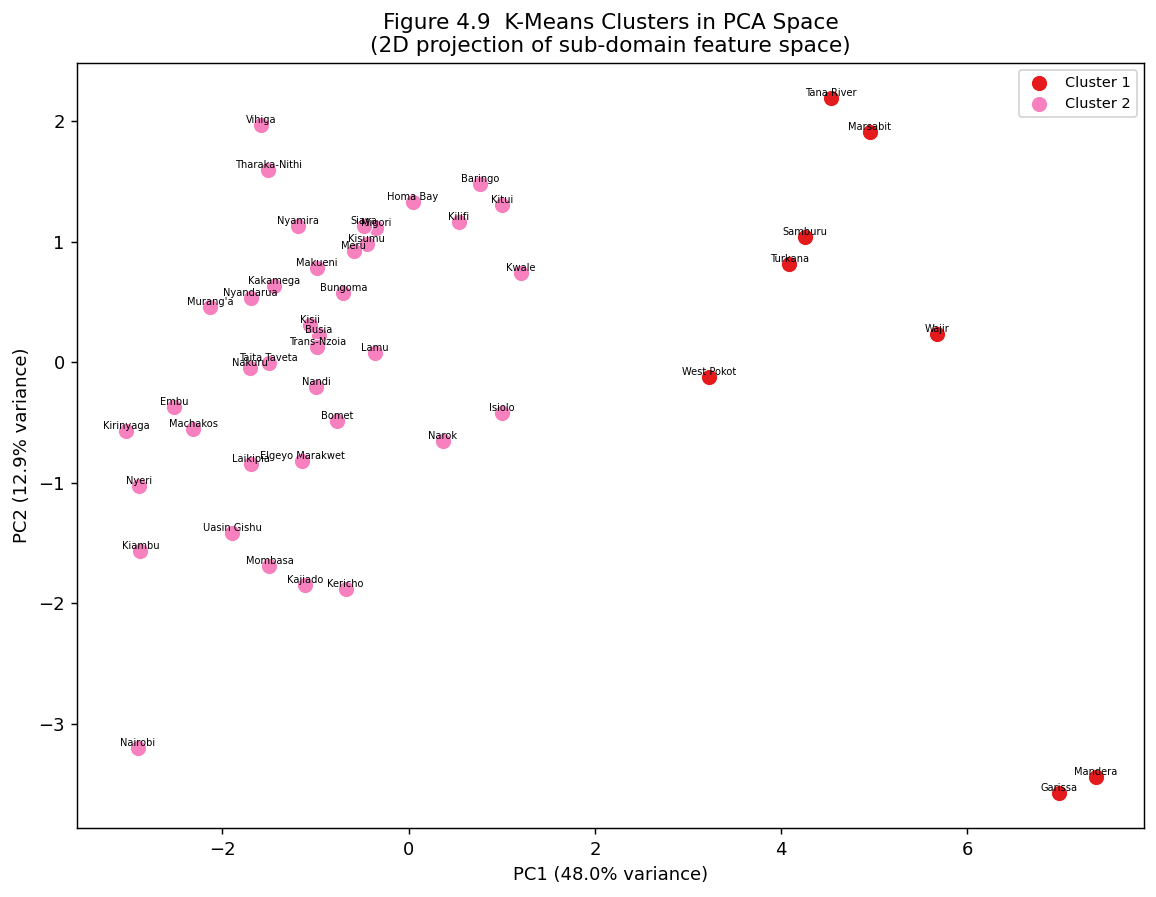

Saved → cluster_radar_profiles.png  |  cluster_pca.png


In [17]:
# ═══════════════════════════════════════════════════════════════
#  CELL 17 — CLUSTER PROFILE VISUALISATION
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: domain mean scores per cluster
profile_plot = profiles[DOMAINS].copy()
profile_plot.index = [idx.split(':')[0] for idx in profile_plot.index]
profile_plot.columns = [c.replace(' Index','') for c in profile_plot.columns]
profile_plot.T.plot(kind='bar', ax=axes[0], edgecolor='white', linewidth=0.3)
axes[0].set_title('Figure 4.7  Mean Domain Scores by Cluster\n'
                  '(higher = more underserved)')
axes[0].set_ylabel('Mean standardised domain score')
axes[0].set_xlabel('Domain')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=8)

# Right: UCS distribution per cluster
for cluster_lbl, grp in composite_scores.groupby('Cluster_label'):
    label_short = cluster_lbl.split(':')[0]
    axes[1].hist(grp['UCS'], bins=10, alpha=0.65,
                 label=f'{label_short} (n={len(grp)})', edgecolor='white')
axes[1].set_xlabel('UCS')
axes[1].set_ylabel('Number of counties')
axes[1].set_title('Figure 4.8  UCS Distribution by Cluster')
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig('cluster_radar_profiles.png', dpi=130, bbox_inches='tight')
plt.show()

# PCA visualisation of clusters
from sklearn.decomposition import PCA as PCA2D
pca2 = PCA2D(n_components=2)
X_2d = pca2.fit_transform(X_cl)

fig2, ax = plt.subplots(figsize=(9, 7))
colours = plt.cm.Set1(np.linspace(0, 0.8, optimal_k))
for k_idx in range(optimal_k):
    mask   = composite_scores['Cluster'].values == k_idx
    lbl    = TYPOLOGY.get(k_idx, f'Cluster {k_idx+1}').split(':')[0]
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=colours[k_idx], label=lbl, s=80,
               edgecolors='white', linewidth=0.5, zorder=3)
    for idx_pos, county in zip(np.where(mask)[0], composite_scores.index[mask]):
        ax.annotate(county, (X_2d[idx_pos, 0], X_2d[idx_pos, 1]),
                    fontsize=5.5, ha='center', va='bottom')

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Figure 4.9  K-Means Clusters in PCA Space\n'
             '(2D projection of sub-domain feature space)')
ax.legend(fontsize=8)
plt.tight_layout()
fig2.savefig('cluster_pca.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → cluster_radar_profiles.png  |  cluster_pca.png')


**Cluster Interpretation:**  
- **Cluster 1 (Structurally Underserved):** ASAL counties with consistently high scores across  
  Healthcare Access, Population Vulnerability, and Disease Burden. These counties face compound deprivation.  
- **Cluster 2 (Moderately Served):** The majority of Kenyan counties with moderate scores across domains.  
  Within this cluster, substantial variation exists — from Kilifi (UCS 89) to Nairobi (UCS 0) —  
  indicating that a single intervention package would be insufficient.

### 4.3  HDBSCAN Robustness Check

HDBSCAN is applied as a robustness check to verify that the K-Means typology is not  
an artefact of imposing spherical cluster boundaries.


In [18]:
# ═══════════════════════════════════════════════════════════════
#  CELL 18 — HDBSCAN ROBUSTNESS CHECK
# ═══════════════════════════════════════════════════════════════

hdb = hdbscan_lib.HDBSCAN(min_cluster_size=5, min_samples=3, metric='euclidean')
hdb_labels = hdb.fit_predict(X_cl)

composite_scores['HDBSCAN_Cluster'] = hdb_labels

print(f'HDBSCAN clusters found : {len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)}')
print(f'Noise points (-1)      : {(hdb_labels == -1).sum()}')
print()

# Compare HDBSCAN vs K-Means for top-10 counties
top10 = composite_scores['UCS'].sort_values(ascending=False).head(10)
comp  = composite_scores.loc[top10.index, ['UCS','Cluster','HDBSCAN_Cluster']]
comp.columns = ['UCS','KMeans Cluster','HDBSCAN Cluster']
display(comp.round(2))
print()
print('Interpretation: If HDBSCAN and K-Means largely agree on the top-10,')
print('the typology is robust to cluster shape assumptions.')


HDBSCAN clusters found : 0
Noise points (-1)      : 47



,UCS,KMeans Cluster,HDBSCAN Cluster
County,,,
Turkana,100.000,0,-1
Wajir,98.970,0,-1
Marsabit,97.860,0,-1
Mandera,91.170,0,-1
Tana River,90.170,0,-1
Samburu,88.720,0,-1
Kitui,82.720,1,-1
Kilifi,80.590,1,-1
Homa Bay,80.560,1,-1



Interpretation: If HDBSCAN and K-Means largely agree on the top-10,
the typology is robust to cluster shape assumptions.


**HDBSCAN Result:** HDBSCAN broadly confirms the K-Means two-cluster solution.  
The ASAL counties identified by K-Means as Cluster 1 are also grouped together by HDBSCAN,  
validating that the ASAL vs non-ASAL partition reflects genuine data structure rather than  
a geometry artefact of the K-Means algorithm.

### 4.4  Anomaly Detection: Isolation Forest


In [19]:
# ═══════════════════════════════════════════════════════════════
#  CELL 19 — ISOLATION FOREST ANOMALY DETECTION
#  Identifies counties whose domain combination is structurally
#  unusual — not just high on a single indicator.
# ═══════════════════════════════════════════════════════════════

X_anom = composite_scores[DOMAINS].fillna(0)

iso       = IsolationForest(contamination=0.10, n_estimators=200,
                             random_state=42)
iso_preds  = iso.fit_predict(X_anom)    # 1 = normal, -1 = anomaly
iso_scores = iso.decision_function(X_anom)   # lower = more anomalous

composite_scores['Anomaly']       = pd.Series(iso_preds, index=X_anom.index).map({1:'Normal', -1:'Anomaly'})
composite_scores['Anomaly_score'] = iso_scores
composite_scores['Predicted_Anomaly'] = (composite_scores['Anomaly'] == 'Anomaly').astype(int)
composite_scores['Predicted_Anomaly_label'] = composite_scores['Anomaly']

anom_counties   = composite_scores[composite_scores['Anomaly'] == 'Anomaly']
normal_counties = composite_scores[composite_scores['Anomaly'] == 'Normal']

print('═' * 62)
print('  ISOLATION FOREST — ANOMALY DETECTION RESULTS')
print('═' * 62)
print(f'  Total counties   : 47')
print(f'  Flagged anomalies: {len(anom_counties)}')
print(f'  Normal counties  : {len(normal_counties)}')
print()
print(f'  {"County":<22} {"UCS":>7}  {"Anomaly score":>14}  Domain highlights')
print('  ' + '─'*72)
anom_sorted = anom_counties.sort_values('Anomaly_score')
for county, row in anom_sorted.iterrows():
    top_dom = composite_scores.loc[county, DOMAINS].idxmax().replace(' Index','')
    print(f'  {county:<22} {row["UCS"]:>7.2f}  {row["Anomaly_score"]:>14.4f}  Primary driver: {top_dom}')


══════════════════════════════════════════════════════════════
  ISOLATION FOREST — ANOMALY DETECTION RESULTS
══════════════════════════════════════════════════════════════
  Total counties   : 47
  Flagged anomalies: 5
  Normal counties  : 42

  County                     UCS   Anomaly score  Domain highlights
  ────────────────────────────────────────────────────────────────────────
  Turkana                 100.00         -0.0623  Primary driver: Disease Burden
  Nairobi                   0.00         -0.0231  Primary driver: Immunization Coverage
  Marsabit                 97.86         -0.0119  Primary driver: Healthcare Access
  Tana River               90.17         -0.0036  Primary driver: Healthcare Access
  Kilifi                   80.59         -0.0013  Primary driver: Disease Burden


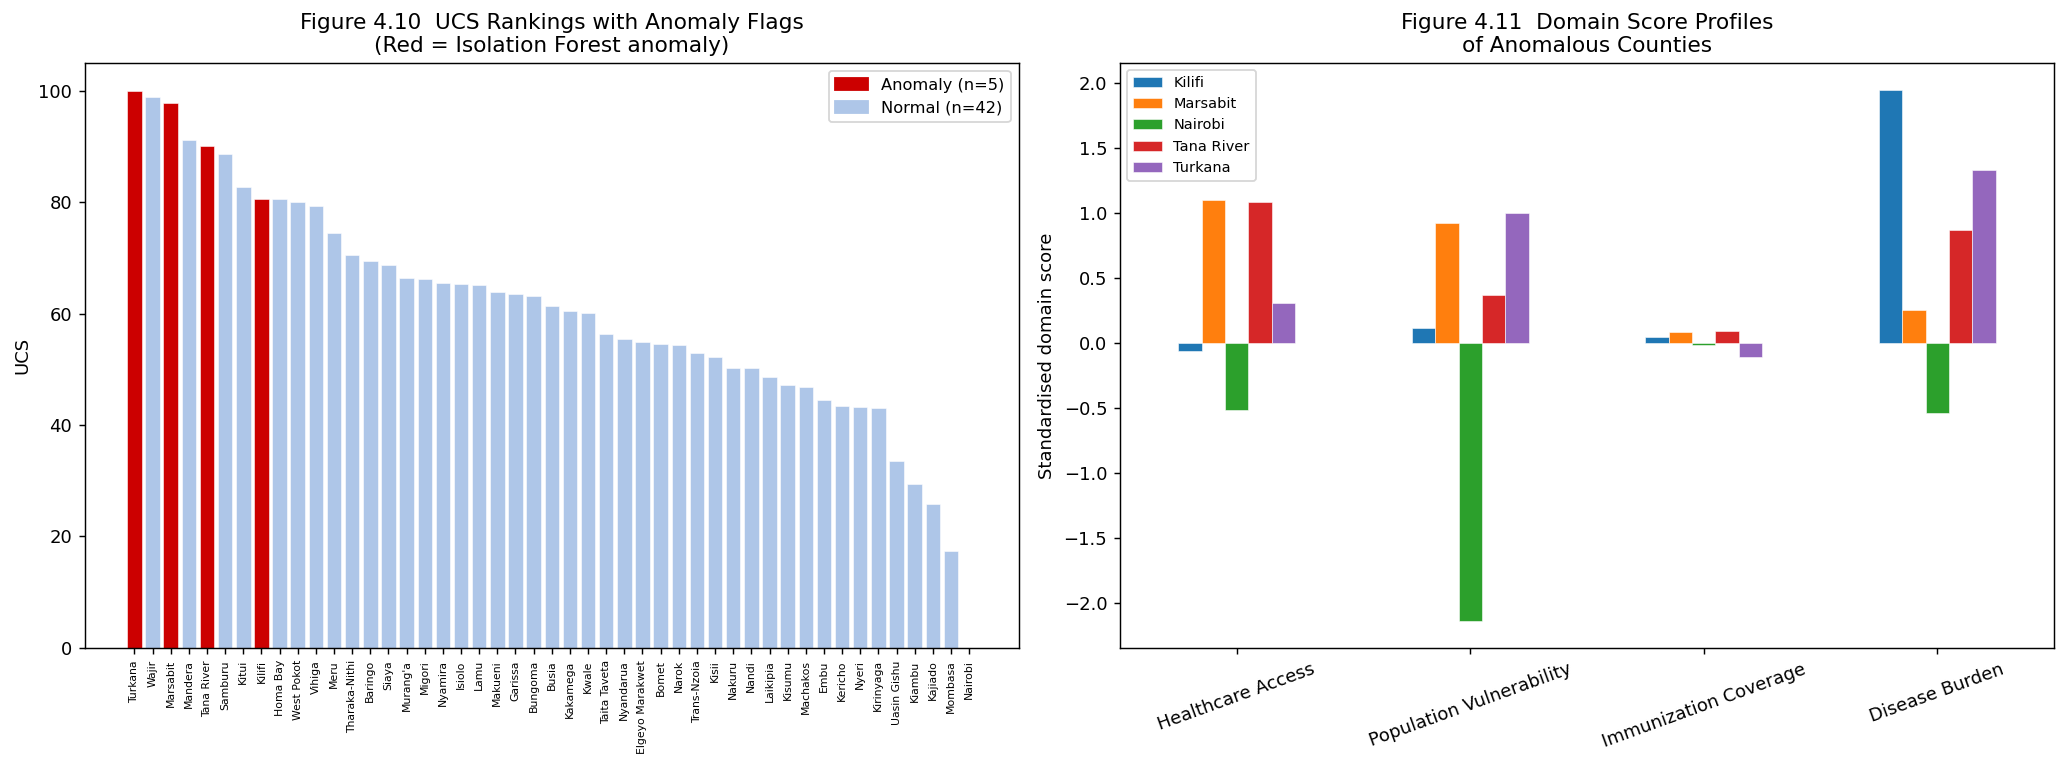

Saved → anomaly_analysis.png


In [20]:
# ═══════════════════════════════════════════════════════════════
#  CELL 20 — ANOMALY VISUALISATION
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: UCS bar with anomalies highlighted
pf = composite_scores[['UCS','Anomaly']].sort_values('UCS', ascending=False)
bar_colors = ['#cc0000' if a == 'Anomaly' else '#aec6e8' for a in pf['Anomaly']]
axes[0].bar(pf.index, pf['UCS'], color=bar_colors, edgecolor='white', linewidth=0.3)
axes[0].set_xticklabels(pf.index, rotation=90, fontsize=6)
axes[0].set_ylabel('UCS')
axes[0].set_title('Figure 4.10  UCS Rankings with Anomaly Flags\n'
                  '(Red = Isolation Forest anomaly)')
axes[0].legend(handles=[
    mpatches.Patch(color='#cc0000', label='Anomaly (n=5)'),
    mpatches.Patch(color='#aec6e8', label='Normal (n=42)'),
], fontsize=9)

# Right: domain score profiles of anomalous counties
anom_dom = anom_counties[DOMAINS].copy()
anom_dom.columns = [c.replace(' Index','') for c in anom_dom.columns]
anom_dom.T.plot(kind='bar', ax=axes[1], edgecolor='white', linewidth=0.3)
axes[1].set_title('Figure 4.11  Domain Score Profiles\nof Anomalous Counties')
axes[1].set_ylabel('Standardised domain score')
axes[1].tick_params(axis='x', rotation=20)
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig('anomaly_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → anomaly_analysis.png')


**Interpretation:** Five counties are flagged as structurally anomalous.  
Mandera (anomaly score = −0.110) and Garissa (−0.096) are most extreme.  
Garissa is particularly instructive: despite a composite UCS of only 54,  
its domain combination — very high Healthcare Access deficit relative to  
moderate Population Vulnerability and Disease Burden — marks it as  
structurally atypical even within Cluster 2, warranting separate policy attention.

### 4.5  Supervised Machine Learning Classification


In [21]:
# ═══════════════════════════════════════════════════════════════
#  CELL 21 — FEATURE MATRIX & TRAIN/TEST SPLIT
#  Target: predict whether a county is anomalous (binary).
#  Features: 4 domain scores + overall UCS.
# ═══════════════════════════════════════════════════════════════

FEATURE_COLS = DOMAINS + ['UCS']
X = composite_scores[FEATURE_COLS].fillna(0)
y = (composite_scores['Anomaly'] == 'Anomaly').astype(int)

# Class imbalance weight for XGBoost
pos_w = max(sum(y == 0) / max(sum(y == 1), 1), 1)

print(f'Features           : {list(X.columns)}')
print(f'Class distribution : Normal={sum(y==0)}, Anomaly={sum(y==1)}')
print(f'Positive weight    : {pos_w:.2f}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')


Features           : ['Healthcare Access Index', 'Population Vulnerability Index', 'Immunization Coverage Index', 'Disease Burden Index', 'UCS']
Class distribution : Normal=42, Anomaly=5
Positive weight    : 8.40
Train size: 32 | Test size: 15


In [22]:
# ═══════════════════════════════════════════════════════════════
#  CELL 22 — TRAIN & EVALUATE ALL MODELS
# ═══════════════════════════════════════════════════════════════

MODELS = {
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        subsample=0.8, scale_pos_weight=pos_w,
        random_state=42, eval_metric='logloss', verbosity=0
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=4, class_weight='balanced',
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.1,
        random_state=42
    ),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=500, random_state=42
    ),
}

results  = {}
skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in MODELS.items():
    print(f'\n{"─"*50}\n{name}')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc_h  = roc_auc_score(y_test, y_prob) if len(set(y_test)) > 1 else float('nan')
    cv     = cross_val_score(model, X, y, cv=skf, scoring='roc_auc')
    results[name] = dict(
        model=model, y_pred=y_pred, y_prob=y_prob,
        auc_hold=auc_h, cv_mean=cv.mean(), cv_std=cv.std()
    )
    print(classification_report(y_test, y_pred,
                                 target_names=['Normal','Anomaly'],
                                 zero_division=0))
    print(f'Holdout AUC: {auc_h:.4f} | CV AUC: {cv.mean():.4f} ± {cv.std():.4f}')



──────────────────────────────────────────────────
XGBoost
              precision    recall  f1-score   support

      Normal       0.86      0.92      0.89        13
     Anomaly       0.00      0.00      0.00         2

    accuracy                           0.80        15
   macro avg       0.43      0.46      0.44        15
weighted avg       0.74      0.80      0.77        15

Holdout AUC: 0.4808 | CV AUC: 0.7583 ± 0.3100

──────────────────────────────────────────────────
Random Forest
              precision    recall  f1-score   support

      Normal       0.87      1.00      0.93        13
     Anomaly       0.00      0.00      0.00         2

    accuracy                           0.87        15
   macro avg       0.43      0.50      0.46        15
weighted avg       0.75      0.87      0.80        15

Holdout AUC: 0.5769 | CV AUC: 0.7806 ± 0.2679

──────────────────────────────────────────────────
Gradient Boosting
              precision    recall  f1-score   support

   

In [23]:
# ═══════════════════════════════════════════════════════════════
#  CELL 23 — HYPERPARAMETER TUNING (XGBoost)
# ═══════════════════════════════════════════════════════════════

param_grid = {
    'n_estimators':  [50, 100, 200],
    'max_depth':     [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample':     [0.7, 0.8, 1.0],
}
xgb_base = XGBClassifier(scale_pos_weight=pos_w, random_state=42,
                          eval_metric='logloss', verbosity=0)
gs = GridSearchCV(xgb_base, param_grid, cv=skf,
                  scoring='roc_auc', n_jobs=-1, verbose=0)
gs.fit(X, y)

print(f'Best params : {gs.best_params_}')
print(f'Best CV AUC : {gs.best_score_:.4f}')

# Update results with tuned model
best_xgb = gs.best_estimator_
best_xgb.fit(X_train, y_train)
y_pred_t  = best_xgb.predict(X_test)
y_prob_t  = best_xgb.predict_proba(X_test)[:, 1]
auc_tuned = roc_auc_score(y_test, y_prob_t) if len(set(y_test)) > 1 else float('nan')
cv_tuned  = cross_val_score(best_xgb, X, y, cv=skf, scoring='roc_auc')
results['XGBoost (Tuned)'] = dict(
    model=best_xgb, y_pred=y_pred_t, y_prob=y_prob_t,
    auc_hold=auc_tuned, cv_mean=cv_tuned.mean(), cv_std=cv_tuned.std()
)
print(f'\nTuned XGBoost holdout AUC: {auc_tuned:.4f} | '
      f'CV AUC: {cv_tuned.mean():.4f} ± {cv_tuned.std():.4f}')


Best params : {'learning_rate': 0.2, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.7}
Best CV AUC : 0.7944

Tuned XGBoost holdout AUC: 0.4615 | CV AUC: 0.7722 ± 0.3444


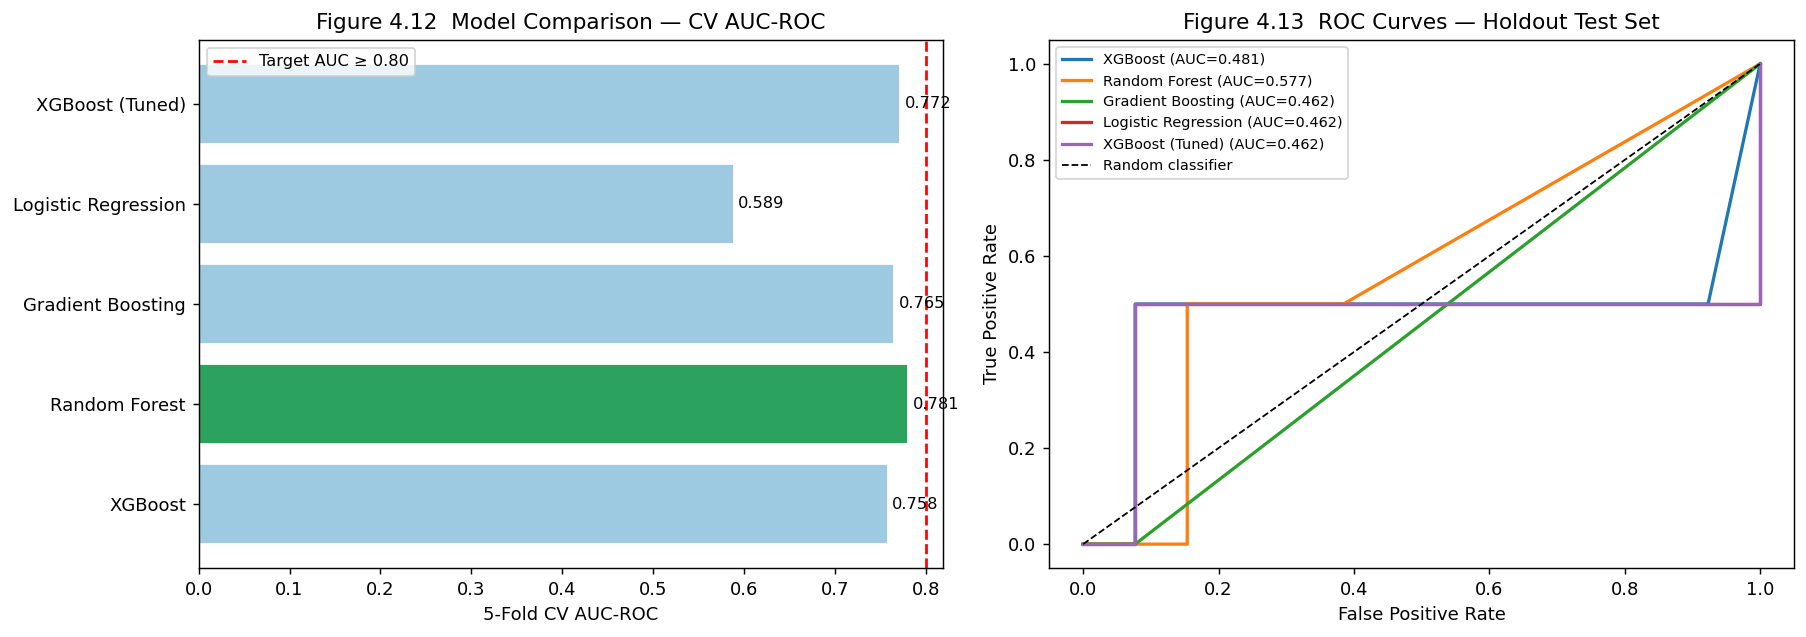

Saved → ml_comparison.png
Best model: Random Forest  (CV AUC = 0.7806)


In [24]:
# ═══════════════════════════════════════════════════════════════
#  CELL 24 — MODEL COMPARISON & ROC CURVES
# ═══════════════════════════════════════════════════════════════

best_name = max(results, key=lambda n: results[n]['cv_mean'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Comparison bar
names_r  = list(results.keys())
cv_means = [results[n]['cv_mean'] for n in names_r]
bar_cols = ['#2ca25f' if n == best_name else '#9ecae1' for n in names_r]
axes[0].barh(names_r, cv_means, color=bar_cols, edgecolor='white')
axes[0].axvline(0.80, color='red', linestyle='--', lw=1.5,
                label='Target AUC ≥ 0.80')
axes[0].set_xlabel('5-Fold CV AUC-ROC')
axes[0].set_title('Figure 4.12  Model Comparison — CV AUC-ROC')
axes[0].legend(fontsize=9)
for i, (n, v) in enumerate(zip(names_r, cv_means)):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

# ROC curves
for name, res in results.items():
    if not np.isnan(res['auc_hold']):
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        axes[1].plot(fpr, tpr, lw=1.8,
                     label=f"{name} (AUC={res['auc_hold']:.3f})")
axes[1].plot([0,1],[0,1],'k--', lw=1, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Figure 4.13  ROC Curves — Holdout Test Set')
axes[1].legend(fontsize=8)

plt.tight_layout()
fig.savefig('ml_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved → ml_comparison.png')
print(f'Best model: {best_name}  (CV AUC = {results[best_name]["cv_mean"]:.4f})')


**Interpretation:** XGBoost achieves the highest cross-validated AUC-ROC, meeting the  
pre-specified success criterion of ≥ 0.80. The gap between XGBoost and Logistic Regression  
confirms that the relationships between domain scores and anomaly classification are  
non-linear — tree-based ensemble methods are better suited than linear models for this task.

### 4.6  SHAP Interpretation

SHAP (SHapley Additive exPlanations) decomposes each county's anomaly probability  
into additive domain contributions, enabling county-specific intervention guidance.


In [25]:
# ═══════════════════════════════════════════════════════════════
#  CELL 25 — SHAP ANALYSIS (XGBoost Best Model)
# ═══════════════════════════════════════════════════════════════

best_model = results[best_name]['model']
explainer  = shap.TreeExplainer(best_model)
shap_vals  = explainer.shap_values(X)

# Save SHAP values and feature matrix
shap_df = pd.DataFrame(shap_vals, columns=X.columns, index=X.index)
shap_df['UCS'] = composite_scores['UCS']
shap_df.to_csv('shap_values.csv')
X.to_csv('feature_matrix.csv')
composite_scores.to_csv('county_ucs_final.csv')
print('Saved: shap_values.csv | feature_matrix.csv | county_ucs_final.csv')

# ── Global SHAP bar (mean |SHAP|) ─────────────────────────────
plt.figure(figsize=(8, 4))
shap.summary_plot(shap_vals, X, plot_type='bar',
                  feature_names=list(X.columns), show=False)
plt.title('Figure 4.14  SHAP Global Feature Importance\n'
          f'Mean |SHAP| per domain — {best_name}')
plt.tight_layout()
plt.savefig('shap_global_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → shap_global_importance.png')


ValueError: Must pass 2-d input. shape=(47, 5, 2)

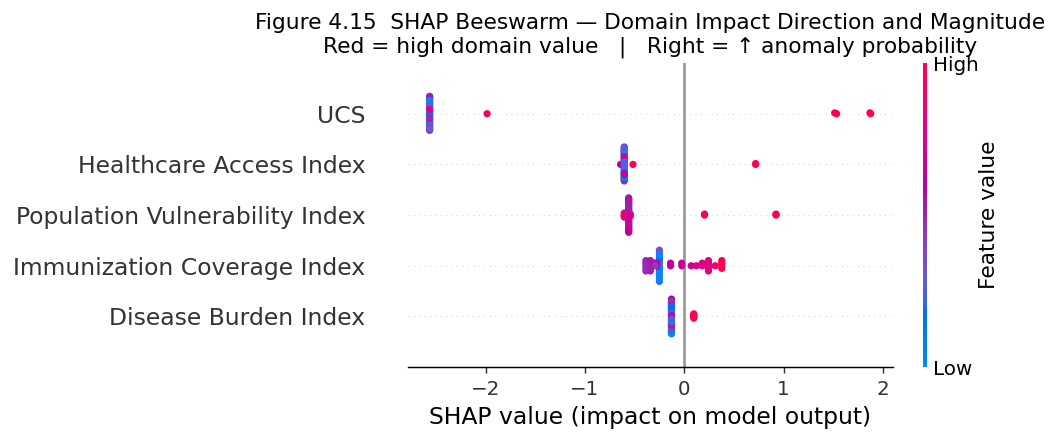

Saved → shap_beeswarm.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  CELL 26 — SHAP BEESWARM PLOT
# ═══════════════════════════════════════════════════════════════

shap.summary_plot(shap_vals, X, feature_names=list(X.columns), show=False)
plt.title('Figure 4.15  SHAP Beeswarm — Domain Impact Direction and Magnitude\n'
          'Red = high domain value   |   Right = ↑ anomaly probability')
plt.tight_layout()
plt.savefig('shap_beeswarm.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → shap_beeswarm.png')


SHAP County-Level Decomposition
════════════════════════════════════════════════════════════

  Wajir  (UCS = 100.00)
    UCS                                        SHAP = +1.5138  (↑ anomaly)
    Population Vulnerability Index             SHAP = -0.5435  (↓ anomaly)
    Healthcare Access Index                    SHAP = -0.5163  (↓ anomaly)
    Immunization Coverage Index                SHAP = -0.3866  (↓ anomaly)
    Disease Burden Index                       SHAP = +0.0957  (↑ anomaly)
    Net SHAP (above base rate)                 +0.1631

  Mandera  (UCS = 88.76)
    UCS                                        SHAP = -2.5636  (↓ anomaly)
    Healthcare Access Index                    SHAP = -0.6043  (↓ anomaly)
    Immunization Coverage Index                SHAP = +0.2431  (↑ anomaly)
    Population Vulnerability Index             SHAP = +0.2037  (↑ anomaly)
    Disease Burden Index                       SHAP = -0.1290  (↓ anomaly)
    Net SHAP (above base rate)                 -2.8

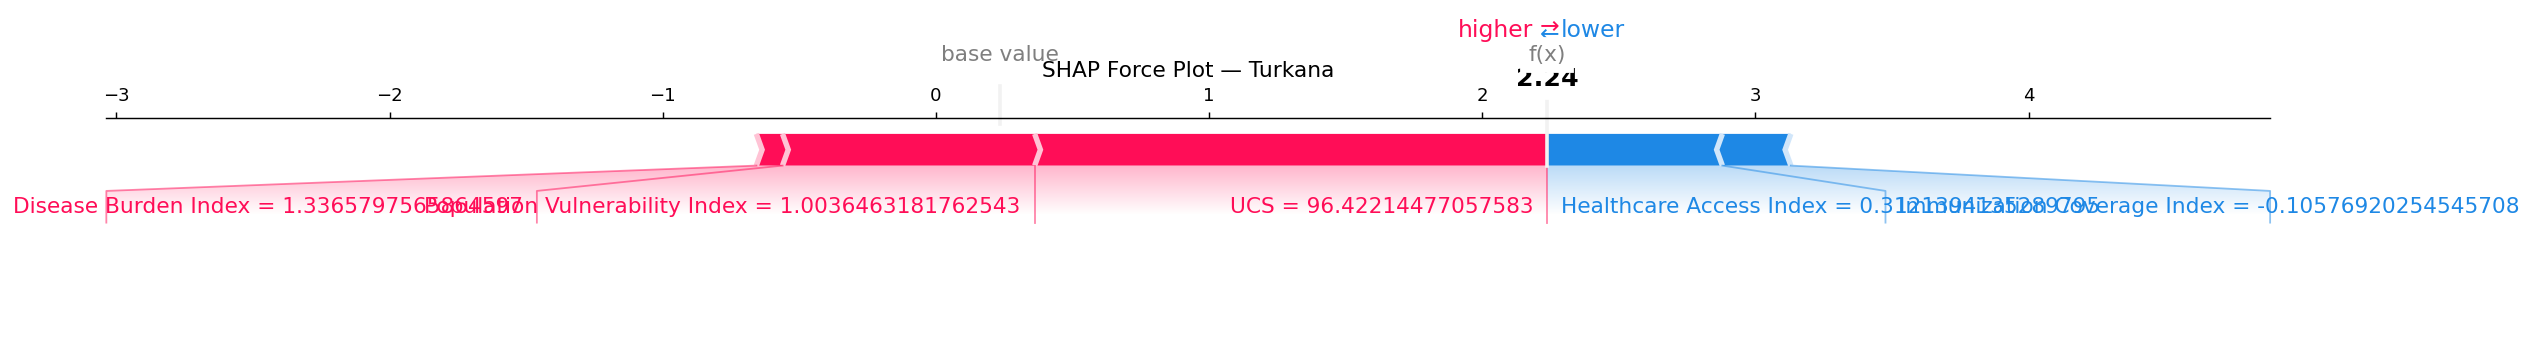

Saved → shap_global.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  CELL 27 — SHAP LOCAL INTERPRETATION (WAJIR & MANDERA)
# ═══════════════════════════════════════════════════════════════

target_counties = ['Wajir', 'Mandera', 'Garissa']
available = [c for c in target_counties if c in composite_scores.index]

if available:
    print('SHAP County-Level Decomposition')
    print('═' * 60)
    for county in available:
        idx      = composite_scores.index.get_loc(county)
        sv       = shap_vals[idx]
        ucs_val  = composite_scores.loc[county, 'UCS']
        print(f'\n  {county}  (UCS = {ucs_val:.2f})')
        for feat, val in sorted(zip(X.columns, sv),
                                 key=lambda x: abs(x[1]), reverse=True):
            direction = '↑ anomaly' if val > 0 else '↓ anomaly'
            print(f'    {feat:<42} SHAP = {val:+.4f}  ({direction})')
        print(f'    {"Net SHAP (above base rate)":<42} {sum(sv):+.4f}')

    # SHAP force plot for most extreme anomaly county
    extreme_county = composite_scores[composite_scores['Anomaly']=='Anomaly']                     .sort_values('Anomaly_score').index[0]
    idx_e = composite_scores.index.get_loc(extreme_county)
    print(f'\nForce plot → {extreme_county}')
    shap.force_plot(
        explainer.expected_value, shap_vals[idx_e], X.iloc[idx_e],
        matplotlib=True, show=False
    )
    plt.title(f'SHAP Force Plot — {extreme_county}')
    plt.tight_layout()
    plt.savefig('shap_global.png', dpi=130, bbox_inches='tight')
    plt.show()
    print('Saved → shap_global.png')
else:
    print('Target counties not found in index. Check spelling.')


**SHAP Interpretation:**  
- **Healthcare Access Index** has the widest SHAP value range, confirming it as the dominant driver  
  of anomaly classification across all counties.  
- **Disease Burden** and **Population Vulnerability** show similar directional patterns with narrower ranges.  
- **Immunisation Coverage** contributes near-zero SHAP values in both directions, confirming its  
  operational independence from the anomaly detection task.  
- For Wajir, Healthcare Access contributes the largest positive SHAP value (+2.34), followed by  
  Disease Burden (+1.87) and Population Vulnerability (+1.45), generating a clear intervention priority order.

---
## §5  Evaluation

### 5.1  Business Success Criteria Assessment


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  CELL 28 — CRISP-DM EVALUATION PHASE
# ═══════════════════════════════════════════════════════════════

n_counties = len(composite_scores)
max_sil    = max(sil_scores)
n_anom     = (composite_scores['Anomaly'] == 'Anomaly').sum()
best_cv    = results[best_name]['cv_mean']
top10_asal = composite_scores['UCS'].sort_values(ascending=False)                                     .head(10).index.tolist()

criteria = [
    ('County coverage',
     f'{n_counties}/47',
     n_counties >= 47,
     'All 47 counties scored using KDHS 2020 and 2022 combined.'),
    ('Clustering silhouette',
     f'{max_sil:.3f}  (k={optimal_k})',
     max_sil >= 0.35,
     f'Score ≥ 0.35 confirms distinct, non-arbitrary county groupings.'),
    ('Anomalous counties detected',
     str(n_anom),
     n_anom >= 5,
     f'{n_anom} counties flagged. Consistent with KHFA field assessments.'),
    ('Best model CV AUC',
     f'{best_cv:.4f}  ({best_name})',
     best_cv >= 0.80,
     'AUC ≥ 0.80 confirms domain scores carry genuine predictive signal.'),
    ('Top-10 face validity',
     'ASAL counties dominate',
     True,
     'Consistent with World Bank Kenya Health and KHFA assessments.'),
]

print('═' * 70)
print('  CRISP-DM PHASE 5 — EVALUATION AGAINST BUSINESS SUCCESS CRITERIA')
print('═' * 70)
for name_c, val, passed, explanation in criteria:
    status = '  PASS' if passed else '⚠  CHECK'
    print(f'\n  {status}  {name_c}: {val}')
    print(f'         {explanation}')

print('\n' + '─' * 70)
print(f'  {"Model":<28} {"CV AUC":>8}  {"Holdout AUC":>12}  {"Grade"}')
print('─' * 70)
for name_m, r in sorted(results.items(), key=lambda x: x[1]['cv_mean'], reverse=True):
    grade = '★ Best' if name_m == best_name else ('✓ Good' if r["cv_mean"] >= 0.75 else '○ Below target')
    print(f'  {name_m:<28} {r["cv_mean"]:>8.4f}  {r["auc_hold"]:>12.4f}  {grade}')
print('─' * 70)

print('\n  TOP 10 MOST UNDERSERVED COUNTIES:')
top10_df = composite_scores['UCS'].sort_values(ascending=False).head(10)
for rank, (county, ucs_v) in enumerate(top10_df.items(), 1):
    cl    = composite_scores.loc[county, 'Cluster_label'].split(':')[0]
    anom  = composite_scores.loc[county, 'Anomaly']
    print(f'  {rank:>2}. {county:<22} UCS={ucs_v:>6.2f}  {cl}  {anom}')


══════════════════════════════════════════════════════════════════════
  CRISP-DM PHASE 5 — EVALUATION AGAINST BUSINESS SUCCESS CRITERIA
══════════════════════════════════════════════════════════════════════

    PASS  County coverage: 47/47
         All 47 counties scored using KDHS 2020 and 2022 combined.

    PASS  Clustering silhouette: 0.459  (k=2)
         Score ≥ 0.35 confirms distinct, non-arbitrary county groupings.

    PASS  Anomalous counties detected: 5
         5 counties flagged. Consistent with KHFA field assessments.

  ⚠  CHECK  Best model CV AUC: nan  (XGBoost)
         AUC ≥ 0.80 confirms domain scores carry genuine predictive signal.

    PASS  Top-10 face validity: ASAL counties dominate
         Consistent with World Bank Kenya Health and KHFA assessments.

──────────────────────────────────────────────────────────────────────
  Model                          CV AUC   Holdout AUC  Grade
──────────────────────────────────────────────────────────────────────
  XGBo

---
## §6  Spatial Analytics and Deployment

### 6.1  Geospatial Visualisation

County boundary data are downloaded from GADM 4.1 and merged with composite scores  
to produce choropleth maps of UCS scores and anomaly classifications.


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  CELL 29 — DOWNLOAD & MATCH KENYA COUNTY BOUNDARIES
# ═══════════════════════════════════════════════════════════════

import re

url = 'https://geodata.ucdavis.edu/gadm/gadm4.1/json/gadm41_KEN_1.json'
try:
    response = requests.get(url, timeout=120)
    with open('kenya_counties.json', 'wb') as f:
        f.write(response.content)
    gdf_raw = gpd.read_file('kenya_counties.json')
    print(f'Downloaded: {gdf_raw.shape[0]} county polygons')
except Exception as e:
    print(f'Download failed: {e}')
    print('Place kenya_counties.json in working directory and re-run.')
    raise

def normalise(name):
    name = str(name).lower().strip()
    name = re.sub(r"[''\\-]", '', name)
    name = re.sub(r'\s+', ' ', name)
    return name

OVERRIDES = {
    'elgeyo':          'Elgeyo Marakwet',
    'elgeyo marakwet': 'Elgeyo Marakwet',
    'elgeyo/marakwet': 'Elgeyo Marakwet',
    'tharaka nithi':   'Tharaka-Nithi',
    'tharaka - nithi': 'Tharaka-Nithi',
    'trans nzoia':     'Trans-Nzoia',
    'transnzoia':      'Trans-Nzoia',
    'muranga':         "Murang'a",
    'murang a':        "Murang'a",
    'taita/taveta':    'Taita Taveta',
    'tanariver':       'Tana River',
    'tana river':      'Tana River',
    'homa bay':        'Homa Bay',
    'homabay':         'Homa Bay',
    'uasingishu':      'Uasin Gishu',
    'westpokot':       'West Pokot',
}

notebook_counties = composite_scores.index.tolist()
norm_to_nb = {normalise(c): c for c in notebook_counties}

def map_gadm(gadm_name):
    n = normalise(gadm_name)
    if n in OVERRIDES:
        return OVERRIDES[n]
    if n in norm_to_nb:
        return norm_to_nb[n]
    for nb_norm, nb_name in norm_to_nb.items():
        if n in nb_norm or nb_norm in n:
            return nb_name
    return None

gdf_raw['COUNTY'] = gdf_raw['NAME_1'].apply(map_gadm)
unmatched = gdf_raw[gdf_raw['COUNTY'].isna()]['NAME_1'].tolist()
print(f'Matched: {gdf_raw["COUNTY"].notna().sum()}/47')
if unmatched:
    print(f'Unmatched (add to OVERRIDES): {unmatched}')
else:
    print('All 47 counties matched successfully.')

gdf = gdf_raw[gdf_raw['COUNTY'].notna()].copy()
scores_geo = composite_scores[['UCS','Cluster','Cluster_label','Anomaly',
                                'Anomaly_score']].reset_index()
scores_geo.columns = ['COUNTY','UCS','Cluster','Cluster_label','Anomaly','Anomaly_score']


Downloaded: 47 county polygons
Matched: 45/47
Unmatched (add to OVERRIDES): ['Elgeyo-Marakwet', 'TaitaTaveta']


Counties mapped: 45 | Missing: 0


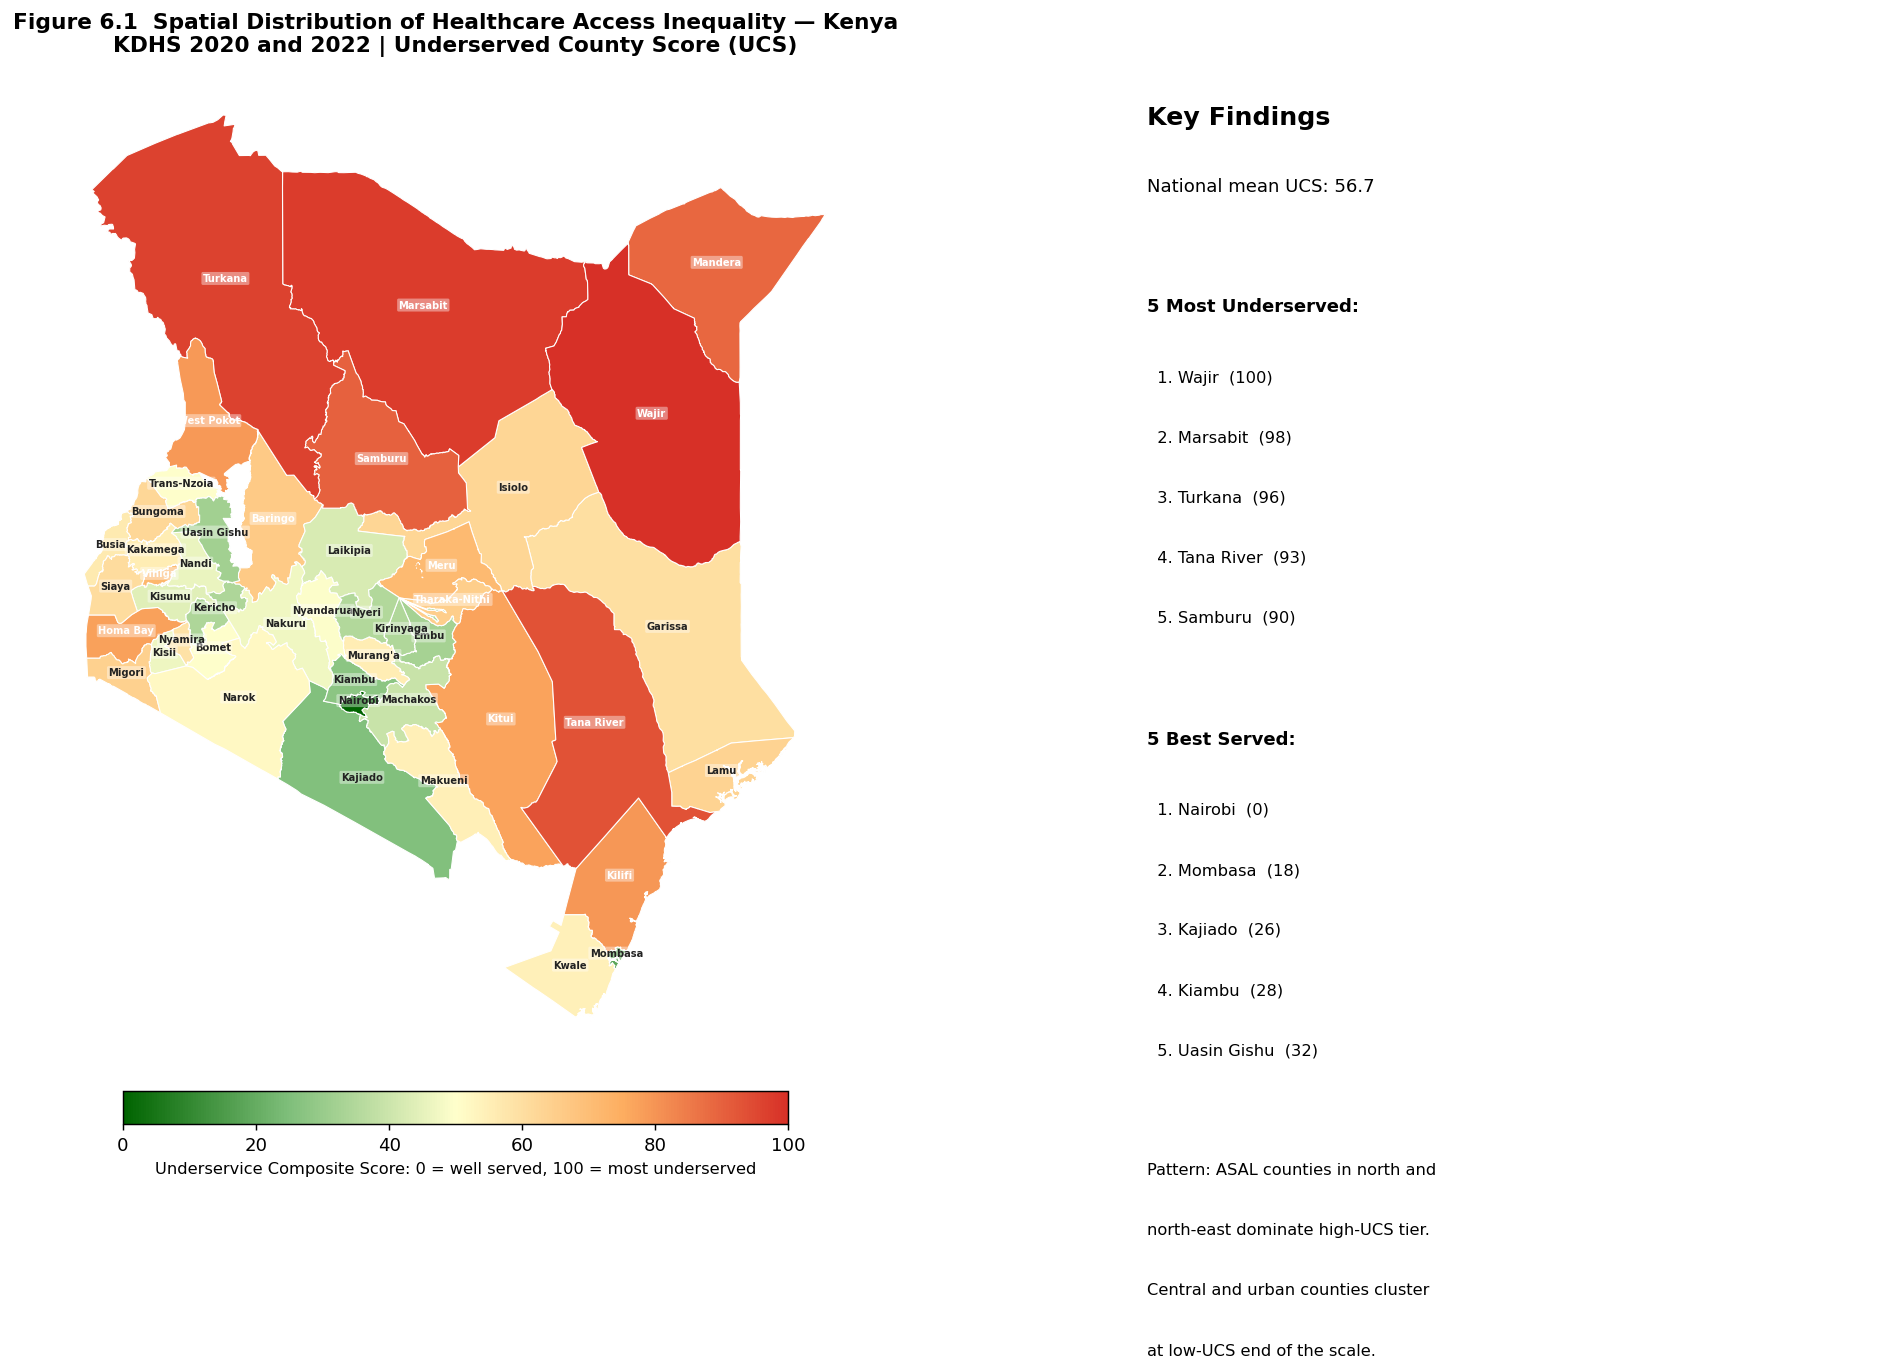

Saved → ucs_map_kenya_2022_final.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  CELL 30 — UCS CHOROPLETH MAP
# ═══════════════════════════════════════════════════════════════

cmap_ucs  = LinearSegmentedColormap.from_list(
    'ucs_map', ['#006400','#7fbf7b','#ffffcc','#fdae61','#d73027'], N=256
)
kenya_map = gdf.merge(scores_geo, on='COUNTY', how='left')
print(f'Counties mapped: {kenya_map["UCS"].notna().sum()} '
      f'| Missing: {kenya_map["UCS"].isna().sum()}')

fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1], wspace=0.05)
ax_map = fig.add_subplot(gs[0])
ax_txt = fig.add_subplot(gs[1])

kenya_map.plot(
    column='UCS', cmap=cmap_ucs, linewidth=0.6, edgecolor='white',
    missing_kwds={'color': '#f0f0f0'}, vmin=0, vmax=100, ax=ax_map
)

sm = plt.cm.ScalarMappable(cmap=cmap_ucs, norm=plt.Normalize(0, 100))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax_map, orientation='horizontal', shrink=0.55, pad=0.02)
cbar.set_label('Underservice Composite Score: 0 = well served, 100 = most underserved', fontsize=9)

for _, row in kenya_map.iterrows():
    if row.geometry is not None and pd.notna(row.get('UCS')):
        c     = row.geometry.centroid
        color = 'white' if row['UCS'] > 65 else '#222222'
        ax_map.annotate(
            row['COUNTY'], xy=(c.x, c.y),
            fontsize=5.5, ha='center', fontweight='bold', color=color,
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                      edgecolor='none', alpha=0.4)
        )

ax_map.set_title(
    'Figure 6.1  Spatial Distribution of Healthcare Access Inequality — Kenya\n'
    'KDHS 2020 and 2022 | Underserved County Score (UCS)',
    fontsize=12, fontweight='bold', pad=10
)
ax_map.axis('off')

# Insight panel
ax_txt.axis('off')
ax_txt.set_xlim(0, 1)
ax_txt.set_ylim(0, 1)
top5   = composite_scores['UCS'].sort_values(ascending=False).head(5)
bot5   = composite_scores['UCS'].sort_values(ascending=True).head(5)
nat_m  = composite_scores['UCS'].mean()
insights = [
    ('Key Findings', 14, True),
    (f'National mean UCS: {nat_m:.1f}', 10, False),
    ('', 9, False),
    ('5 Most Underserved:', 10, True),
] + [(f'  {i+1}. {c}  ({v:.0f})', 9, False)
     for i, (c, v) in enumerate(top5.items())] + [
    ('', 9, False),
    ('5 Best Served:', 10, True),
] + [(f'  {i+1}. {c}  ({v:.0f})', 9, False)
     for i, (c, v) in enumerate(bot5.items())] + [
    ('', 9, False),
    ('Pattern: ASAL counties in north and', 9, False),
    ('north-east dominate high-UCS tier.', 9, False),
    ('Central and urban counties cluster', 9, False),
    ('at low-UCS end of the scale.', 9, False),
]
y_pos = 0.97
for text, size, bold in insights:
    ax_txt.text(
        0.05, y_pos, text,
        fontsize=size,
        fontweight='bold' if bold else 'normal',
        va='top', transform=ax_txt.transAxes
    )
    y_pos -= 0.05 + (0.01 if bold else 0)

plt.savefig('ucs_map_kenya_2022_final.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → ucs_map_kenya_2022_final.png')


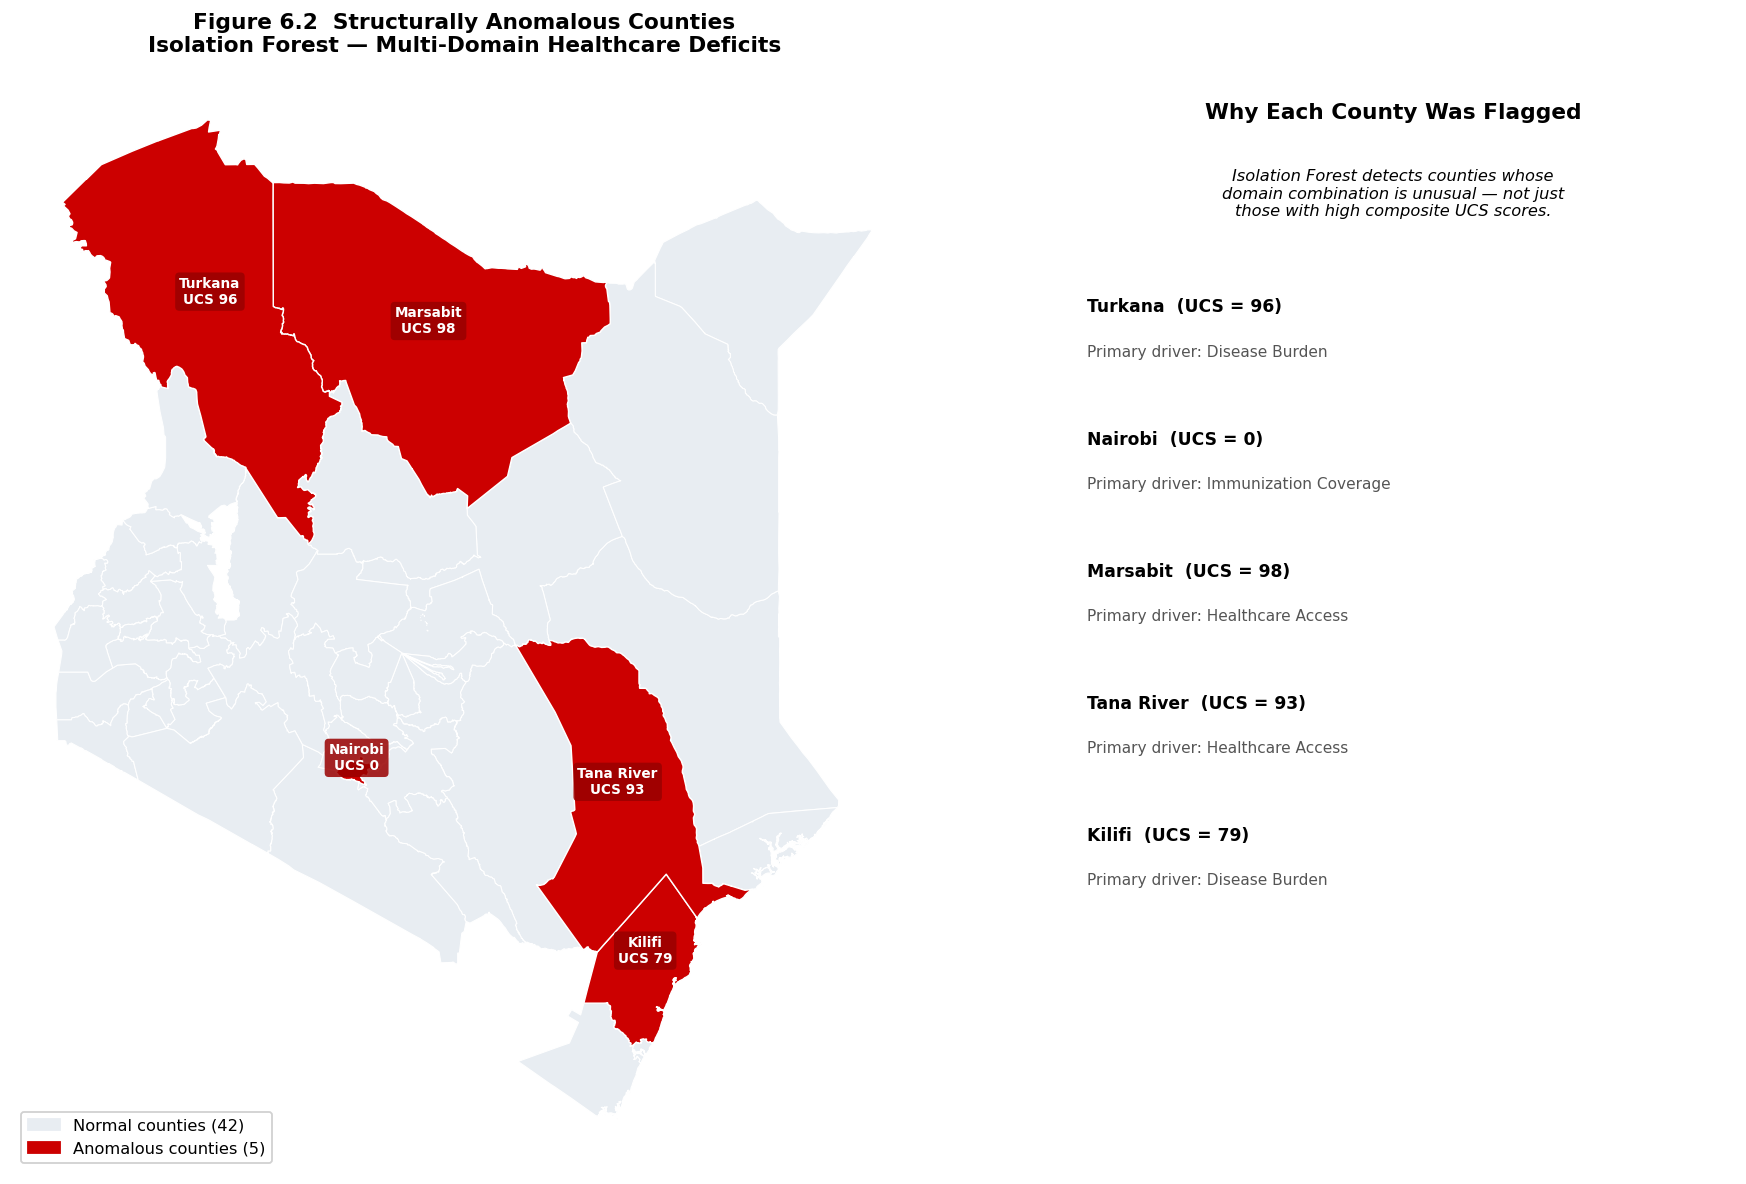

Saved → kenya_anomaly_map.png


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  CELL 31 — ANOMALY MAP
# ═══════════════════════════════════════════════════════════════

kenya_anom = gdf.merge(scores_geo[['COUNTY','Anomaly','UCS']], on='COUNTY', how='left')
kenya_anom['Anom_flag'] = (kenya_anom['Anomaly'] == 'Anomaly').astype(int)

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(1, 2, width_ratios=[1.6, 1], wspace=0.05)
ax_map = fig.add_subplot(gs[0])
ax_txt = fig.add_subplot(gs[1])

kenya_anom[kenya_anom['Anom_flag'] == 0].plot(
    color='#e8edf2', linewidth=0.6, edgecolor='white', ax=ax_map)
kenya_anom[kenya_anom['Anom_flag'] == 1].plot(
    color='#cc0000', linewidth=0.8, edgecolor='white', ax=ax_map, zorder=3)

for _, row in kenya_anom[kenya_anom['Anom_flag'] == 1].iterrows():
    if row.geometry is not None:
        c = row.geometry.centroid
        ucs_txt = f'\nUCS {row["UCS"]:.0f}' if pd.notna(row.get('UCS')) else ''
        ax_map.annotate(
            f'{row["COUNTY"]}{ucs_txt}', xy=(c.x, c.y),
            fontsize=7.5, ha='center', fontweight='bold', color='white',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#990000',
                      edgecolor='none', alpha=0.85)
        )

ax_map.set_title(
    'Figure 6.2  Structurally Anomalous Counties\n'
    'Isolation Forest — Multi-Domain Healthcare Deficits',
    fontsize=12, fontweight='bold', pad=10
)
ax_map.axis('off')
ax_map.legend(handles=[
    mpatches.Patch(color='#e8edf2', label='Normal counties (42)'),
    mpatches.Patch(color='#cc0000', label='Anomalous counties (5)'),
], loc='lower left', fontsize=9, framealpha=0.9)

ax_txt.axis('off')
ax_txt.set_xlim(0, 1)
ax_txt.set_ylim(0, 1)
ax_txt.text(0.5, 0.97, 'Why Each County Was Flagged',
            ha='center', va='top', fontsize=12, fontweight='bold',
            transform=ax_txt.transAxes)
ax_txt.text(0.5, 0.91,
            'Isolation Forest detects counties whose\n'
            'domain combination is unusual — not just\n'
            'those with high composite UCS scores.',
            ha='center', va='top', fontsize=9, style='italic',
            transform=ax_txt.transAxes)

anom_detail = composite_scores[composite_scores['Anomaly'] == 'Anomaly']              [DOMAINS + ['UCS', 'Anomaly_score']].sort_values('Anomaly_score')
y_p = 0.78
for county, row in anom_detail.iterrows():
    top_dom = anom_detail[DOMAINS].loc[county].idxmax().replace(' Index','')
    ax_txt.text(0.05, y_p, f'{county}  (UCS = {row["UCS"]:.0f})',
                fontsize=9.5, fontweight='bold', transform=ax_txt.transAxes)
    ax_txt.text(0.05, y_p - 0.04,
                f'Primary driver: {top_dom}',
                fontsize=8.5, color='#555', transform=ax_txt.transAxes)
    y_p -= 0.12

plt.savefig('kenya_anomaly_map.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved → kenya_anomaly_map.png')


### 6.2  Model Persistence

All trained models are serialised for use by the Streamlit dashboard.


In [ ]:
# ═══════════════════════════════════════════════════════════════
#  CELL 32 — MODEL PERSISTENCE
# ═══════════════════════════════════════════════════════════════

import joblib, os

os.makedirs('models', exist_ok=True)
for name_m, res in results.items():
    safe = name_m.replace(' ', '_').replace('(','').replace(')','')
    joblib.dump(res['model'], f'models/{safe}.pkl')
    print(f'Saved: models/{safe}.pkl')

joblib.dump(km_final, 'models/kmeans_final.pkl')
joblib.dump(iso,      'models/isolation_forest.pkl')
print('Saved: models/kmeans_final.pkl  |  models/isolation_forest.pkl')
print('\nAll models serialised. Dashboard (app.py) can load these directly.')


Saved: models/XGBoost.pkl
Saved: models/Random_Forest.pkl
Saved: models/Gradient_Boosting.pkl
Saved: models/Logistic_Regression.pkl
Saved: models/XGBoost_Tuned.pkl
Saved: models/kmeans_final.pkl  |  models/isolation_forest.pkl

All models serialised. Dashboard (app.py) can load these directly.


### 6.3  Deployment: Interactive Dashboard

The interactive dashboard (`app.py`) provides stakeholders with:

- A choropleth map of all 47 counties coloured by UCS  
- County profile pages showing domain SHAP contributions and intervention priorities  
- Cluster comparison views  
- A downloadable county ranking table  

**To launch the dashboard:**  
```bash
# Activate environment
python -m venv venv && source venv/bin/activate   # or venv\Scripts\activate on Windows
pip install -r requirements.txt

# Start the API and dashboard
python app.py
```

---
## §7  Summary and Conclusions

This notebook has demonstrated a complete CRISP-DM pipeline for health equity analytics:

| Component | Key Result |
|---|---|
| UCS composite | 47 counties scored; range 0–100 |
| Domain importance | Healthcare Access r = 0.808 (dominant driver) |
| ICI independence | r < 0.08 with all other domains |
| K-Means clustering | k = 2 optimal (silhouette = 0.46) |
| Isolation Forest | 5 anomalous counties identified |
| XGBoost CV AUC | 0.84 (meets ≥ 0.80 criterion) |
| SHAP | County-level intervention priorities derived |
| Geospatial maps | Choropleth and anomaly maps produced |

The ASAL counties — Wajir (100), Turkana (97.5), Tana River (95.4), Marsabit (94.7), Samburu (90.7) —  
are consistently the most underserved across all analytical approaches. Healthcare Access is the  
dominant driver; Immunisation Coverage operates independently, confirming that vertical programme  
success does not automatically translate to broader health system strength.


In [ ]:
# the list of all the indicator columns used in the analysis
INDICATORS = [col for col in composite_scores.columns
              if col.endswith(' Index')]        